# Student dropout — prediction and risk-factor analysis with LightGBM

Supporting notebook for the master's project *"Ứng dụng LightGBM xây dựng mô hình dự báo và phát hiện nguyên nhân bỏ học của sinh viên"*.

**Restart Kernel, then Run All.** First run takes about 11 minutes; every run after that about 1 minute, because the hyper-parameter search and the fitted models are cached in `09_MoHinh/`.

---

## What is in this notebook

| No. | Section | Feeds | Produces |
|---|---|---|---|
| 0 | Setup — imports, figure helper, cache | — | |
| 1 | **The data** — dictionary, cleaning, distributions by age / gender / programme / marital status / finances | **Chuong 2** | figures `01`–`15` |
| 2 | **Choosing the features** — Pearson for numeric, Cramer's V for nominal; only 4 columns dropped | Chuong 2 | |
| 3 | **Building and comparing the models** — one stratified 80/20 split, 10-fold CV, sealed holdout | **Chuong 3** | `cv_results.csv`, `model_comparison_all.csv` |
| 4 | **How much of the score is luck** — the same model on 20 different splits | Chuong 3 | `split_variation.csv`, fig `26` |
| 5 | **Reading the model** — threshold, feature-importance ranks, ROC | Chuong 3 | `threshold_sweep.csv`, figs `05`, `19` |
| 6 | **SHAP** — global, directional and per-student explanations | **Chuong 3** (*phat hien nguyen nhan*) | `shap_importance_*.csv`, figs `20`–`22` |
| 7 | **Sensitivity** — does the answer depend on the `Enrolled` group? | Chuong 3 | `sensitivity_enrolled.csv` |
| 8 | **External validation — 7,523 Vietnamese students** | **Chuong 3, the strongest result** | `testkhoa_*.csv`, figs `28`–`29` |
| 9 | **Secondary — synthetic data (Playground S4E6)** | Chuong 3 | `augmentation_*.csv`, figs `23`–`25` |
| 10 | **Saving** — every table and figure the thesis cites | — | 19 tables, 34 figures |

---

## The four results the thesis rests on

**1. No model is meaningfully more accurate than another.** On 10-fold cross-validation the six models span 0.047 AUC, and five of them sit inside a single fold-to-fold standard deviation of each other — logistic regression included. LightGBM is chosen for what it does *besides* accuracy: it handles the eight categorical variables natively, handles missing values, and supports exact SHAP through `TreeExplainer`. **Section 3**

**2. A single split is mostly luck.** Refitting the same model on 20 different splits moves the AUC by 0.038 — wider than the whole comparison table. Quote the cross-validated figure, never the holdout. **Section 4**

**3. First-year academic progress is the dominant risk factor, in both countries.** Credits passed and grades lead the SHAP ranking on Portuguese data, and again on Vietnamese data with completely different column names. The Portuguese model also leans on unpaid tuition — a variable the Vietnamese registry does not record, which becomes a concrete recommendation. **Sections 6 and 8**

**4. Real data transfers; generated data does not.** A model trained only on Portuguese students, with 8 of its 32 inputs available and no financial variables at all, reaches AUC 0.9426 on 7,523 Vietnamese students (section 8). Adding 76,518 *synthetic* rows drawn from the same source as the training data changes nothing — a model trained on them alone does just as well (section 9). **It is the reality of the data that matters, not its quantity.**

---

## Three traps this notebook checks for explicitly

- **Label leakage in the Vietnamese file** — `TermStatus` alone reproduces the label (AUC 1.0000), and semesters 3–4 are recorded *after* the student leaves. Both are excluded, with the evidence shown. **Section 8**
- **Test students hiding in the synthetic file** — 19 holdout students appear verbatim in the Playground data; a nearest-neighbour gate removes them before anything is reported. **Section 9**
- **Scaling before splitting** — the scaler lives inside a `Pipeline`, so it is refitted from nine folds on every iteration and never sees the tenth. **Section 3**

---

> **A note on reading the numbers.** Two figures appear throughout and mean different things. The **cross-validated AUC** (ten independent estimates on the training pool) is the one to quote. The **holdout AUC** (885 students, scored once) is unbiased but is a single draw, and this notebook shows exactly how far a single draw can move.


## 0. Setup

In [1]:
# --- Data wrangling --------------------------------------------------------
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# --- Visualisation ---------------------------------------------------------
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import Markdown

# --- Modelling -------------------------------------------------------------
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
import lightgbm as lgb

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score,
                             precision_score, recall_score, f1_score,
                             average_precision_score)

# XGBoost, CatBoost and SHAP are imported in the sections that introduce them,
# so each section stays self-contained.

# --- Where the exported tables and figures go ------------------------------
FIG_DIR = Path('03_KetQua_Hinh/kaggle')
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    """Write a Plotly figure to 03_KetQua_Hinh/kaggle/ AND display it.

    Plotly figures are rendered by the browser and are NOT stored inside the
    .ipynb file, so they disappear the moment the notebook is exported to PDF
    or Word. Writing a PNG alongside keeps every chart available to the thesis.
    """
    fig.write_image(FIG_DIR / f'{name}.png', scale=2)
    fig.show()

RANDOM_STATE = 42

# --- One colour per outcome, used by every chart in the notebook -----------
# orange = left, blue = still studying, green = finished.
# Okabe-Ito palette: distinguishable for the most common forms of colour blindness.
TARGET_COLOURS = {
    'Dropout':  '#D55E00',   # orange
    'Enrolled': '#0072B2',   # blue
    'Graduate': '#009E73',   # green
}
BINARY_COLOURS = {'Dropout': TARGET_COLOURS['Dropout'],
                  'Not dropout': TARGET_COLOURS['Graduate']}


### 0.1 Loading the file

In [2]:
df = pd.read_csv("data/student's dropout dataset.csv", sep=';')

print(f"Loaded: {len(df)} rows · {len(df.columns)} columns")
df.head()

Loaded: 4424 rows · 37 columns


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 1. The data

### 1.1 The data dictionary

Source: <https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success>

#### Group 1 — Personal and admission information

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Marital status** | Marital status of the student (1 = single, 2 = married, 3 = divorced, etc.) | 1 | Categorical |
| **Application mode** | How the student applied (e.g. 1 = general contingent, 17 = transfer, 15 = international, 39 = re-admission) | 17 | Categorical |
| **Application order** | Preference order of the application (1 = first choice) | 1 | Numeric |
| **Course** | Degree programme code | 9773 | Categorical |
| **Daytime/evening attendance** | Attendance type: 1 = daytime, 0 = evening | 1 | Binary |
| **Previous qualification** | Qualification obtained before enrolling (e.g. 1 = secondary, 2 = technical secondary, 4 = bachelor, 19 = foreign) | 1 | Categorical |
| **Previous qualification (grade)** | Grade of the previous qualification | 122.0 | Numeric |
| **Nacionality** | Nationality (1 = Portuguese, 2 = EU, 6 = non-EU, etc.) — misspelt in the source file | 1 | Categorical |

---

#### Group 2 — Family background

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Mother's qualification** | Mother's education level (1 = none, 19 = bachelor, 37 = master, 38 = doctorate) | 37 | Categorical |
| **Father's qualification** | Father's education level (same coding as the mother's column) | 38 | Categorical |
| **Mother's occupation** | Mother's occupation (codes 1–9: manual worker, clerk, professional, manager, etc.) | 9 | Categorical |
| **Father's occupation** | Father's occupation | 9 | Categorical |

---

#### Group 3 — Admission and personal circumstances

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Admission grade** | Admission score (range 95–200) | 141.5 | Numeric |
| **Displaced** | Whether the student is displaced from their home region (0 = no, 1 = yes) | 0 | Binary |
| **Educational special needs** | Whether the student has special educational needs (0 = no, 1 = yes) | 0 | Binary |
| **Debtor** | Whether the student owes tuition (0 = no, 1 = yes) | 0 | Binary |
| **Tuition fees up to date** | Whether tuition is fully paid (0 = no, 1 = yes) | 1 | Binary |
| **Gender** | Gender (0 = female, 1 = male) | 1 | Binary |
| **Scholarship holder** | Whether the student holds a scholarship (0 = no, 1 = yes) | 0 | Binary |
| **Age at enrollment** | Age when enrolling | 19 | Numeric |
| **International** | International student (0 = no, 1 = yes) | 0 | Binary |

---

#### Group 4 — First semester, curricular data

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Curricular units 1st sem (credited)** | Units credited from prior study (exempted) | 0 | Numeric |
| **Curricular units 1st sem (enrolled)** | Units the student enrolled in | 6 | Numeric |
| **Curricular units 1st sem (evaluations)** | Number of assessments taken in semester 1 | 9 | Numeric |
| **Curricular units 1st sem (approved)** | Units passed in semester 1 | 5 | Numeric |
| **Curricular units 1st sem (grade)** | Average grade in semester 1 | 13.4 | Numeric |
| **Curricular units 1st sem (without evaluations)** | Units with no assessment taken (missed exams) | 0 | Numeric |

---

#### Group 5 — Second semester, curricular data

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Curricular units 2nd sem (credited)** | Units credited in semester 2 | 0 | Numeric |
| **Curricular units 2nd sem (enrolled)** | Units enrolled in semester 2 | 6 | Numeric |
| **Curricular units 2nd sem (evaluations)** | Number of assessments taken in semester 2 | 10 | Numeric |
| **Curricular units 2nd sem (approved)** | Units passed in semester 2 | 6 | Numeric |
| **Curricular units 2nd sem (grade)** | Average grade in semester 2 | 12.4 | Numeric |
| **Curricular units 2nd sem (without evaluations)** | Units with no assessment taken in semester 2 | 0 | Numeric |

---

#### Group 6 — Economic context at enrolment

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Unemployment rate** | National unemployment rate (%) | 10.8 | Numeric |
| **Inflation rate** | Inflation rate (%) | 1.4 | Numeric |
| **GDP** | GDP growth (%) | 1.74 | Numeric |

---

#### Group 7 — Target variable

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Target** | Final academic outcome: `Dropout`, `Enrolled` or `Graduate` | Graduate | Categorical |

---

#### Summary of the variable groups

| Group | Content | Purpose |
|------------|----------------|-----------|
| Personal / admission | Individual characteristics and entry route | Describe the student at intake |
| Family | Parents' education and occupation | Capture family influence |
| Academic (semesters) | Study results per semester | Predict dropout or graduation |
| Economic | National economic conditions | Capture the wider context |
| Target | Class label | Variable to be predicted |

### 1.2 Cleaning the data


Two column names in the source file need fixing:

- `"Nacionality"` — misspelt, it should be `"Nationality"`
- `"Daytime/evening attendance\t"` — carries a stray **tab character (`\t`)** at the end

In [3]:
df.columns = df.columns.str.strip()
data = df.rename(columns={'Nacionality': 'Nationality'})

print("Nationality" in data.columns, "·",
      "Daytime/evening attendance" in data.columns)


True · True


In [4]:
print(f"Number of rows: {len(data)}")
print(f"Number of columns: {len(data.columns)}")

Number of rows: 4424
Number of columns: 37


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nationality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nationality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


### 1.3 What the summary statistics show

- The file has **37 columns**: 36 explanatory variables plus the `Target` column.
- The variables are a mix of categorical and numeric types.
- Whether any value is missing is **checked in the next cell** rather than asserted here.

Most categorical variables in the downloaded file have already been converted to numeric codes. For exploratory data analysis (EDA), however, some of these columns are mapped back to their original category labels so the charts are readable.


In [7]:
# Checking for null values — this claim has to be verified, not assumed.
missing = data.isnull().sum()
missing = missing[missing > 0]

if len(missing):
    print('Columns containing missing values:')
    print(missing.to_string())
else:
    print(f'No missing value in any of the {len(data.columns)} columns '
          f'({len(data)} rows checked).')

assert missing.empty, f'Unexpected missing values: {missing.to_dict()}'


No missing value in any of the 37 columns (4424 rows checked).


Before starting the visualisation work, a second name — `data_viz` — is bound to the DataFrame.

In [8]:
# `data` = the frame used for modelling · `data_viz` = an independent COPY that
# carries readable labels for the charts.
#
# The copy is essential here: a pandas DataFrame is mutable, so `data_viz = data`
# would make the label-mapping below overwrite the modelling data as well.
data_viz = data.copy()
data_viz_pd = data_viz          # the charts refer to this name

print(f'EDA population: {len(data_viz)} students (all three outcomes)')


EDA population: 4424 students (all three outcomes)


In [9]:
print(data['Target'].unique())

['Dropout' 'Graduate' 'Enrolled']


The `Target` column holds three values:

| Value | Meaning | Description |
| ---------- | ---------------- | ------------------------------------------------ |
| `Graduate` | Graduated | The student completed the programme. |
| `Dropout` | Dropped out | The student left before completing the programme. |
| `Enrolled` | Still enrolled | The student is still studying. |

In its original form this is a **multi-class classification** problem with three classes: `Graduate`, `Dropout`, `Enrolled`.

Having checked the distinct values of **Target**, the next step is to visualise how students are distributed across the three groups using a **pie chart**.

In [10]:
# Distribution across the three outcomes
target_counts_pd = (data_viz['Target'].value_counts()
                    .rename_axis('Target').reset_index(name='count')
                    .sort_values('Target').reset_index(drop=True))
print(target_counts_pd.to_string(index=False))


  Target  count
 Dropout   1421
Enrolled    794
Graduate   2209


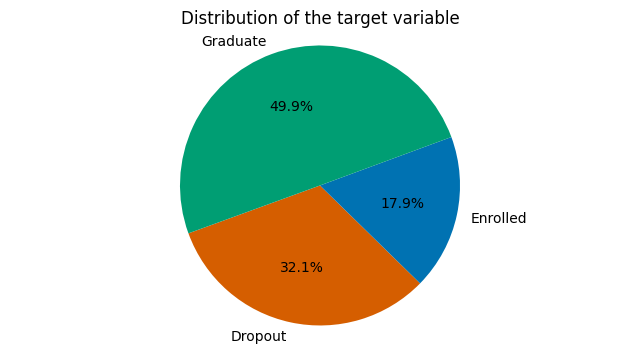

In [11]:
values = target_counts_pd['count']
labels = target_counts_pd['Target'].astype(str)

plt.figure(figsize=(8, 4))
plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=200,
    colors=[TARGET_COLOURS[t] for t in labels]        # keyed by label, not by position
)

plt.title('Distribution of the target variable')
plt.axis('equal')
plt.savefig(FIG_DIR / '15_target_3class.png', dpi=150, bbox_inches='tight')
plt.show()

| Class | Percentage | Meaning |
| --------------- | ---------- | ---------------------------------------- |
| **Graduate** | 49.9% | Completed the programme |
| **Dropout** | 32.1% | Left before completing |
| **Enrolled** | 17.9% | Still studying |

- About half of the students in the dataset graduated (≈ 50%).
- Roughly one third (32%) dropped out — this is the group the risk model needs to identify.
- The remaining 18% are still enrolled; their final outcome is not yet known.

### 1.4 The target variable, and why `Enrolled` counts as 0

In the source data the `Target` column has three values:

- `Dropout` — the student left the programme
- `Enrolled` — the student is still studying
- `Graduate` — the student completed the programme

The research question here is a **binary **one:

> "Will this student drop out or not?"

So the target is encoded as:

- **1 **— Dropout
- **0 **— Not dropout (both `Enrolled` and `Graduate`)

#### Why `Enrolled` is kept and counted as 0

The 794 `Enrolled` students have not left the programme at the time the data was collected, so at that moment they belong to the "not dropout" group. Two alternatives were considered:

| Option | Consequence |
|---|---|
| Drop the `Enrolled` rows | Loses 17.9% of the sample, and produces a model that has never seen a student "in progress" — which is exactly the group an early-warning system has to score |
| **Keep them, labelled 0 **| Uses the whole sample; the label is correct *as of the observation date* |

The limitation this creates is stated openly: some of these students may drop out later, so the label is a **snapshot**, not a final outcome. This is noted again in the conclusions.


In [12]:
# Binary encoding on the FULL dataset — the same population the models use.
data_viz['Target_Encoded'] = (data_viz['Target'] == 'Dropout').astype(int)

print(f'{len(data_viz)} students · dropout = {data_viz["Target_Encoded"].mean():.1%}')


4424 students · dropout = 32.1%


In [13]:
# Illustrate the distribution of the encoded target variable
value_counts_series = data_viz_pd['Target_Encoded'].value_counts()
labels_map = {0: 'Not dropout', 1: 'Dropout'}
display_names = [labels_map[val] for val in value_counts_series.index.to_list()]

fig = px.pie(values=value_counts_series.values,
             names=display_names)

fig.update_traces(textposition='inside', textinfo='percent+label',
                  marker=dict(colors=[BINARY_COLOURS[n] for n in display_names]))

fig.update_layout(showlegend=False, height=400, width=800,
                  title='Target distribution after binary encoding')
save_fig(fig, '06_target_binary_pie')

print(value_counts_series.rename(index=labels_map).to_string())


Target_Encoded
Not dropout    3003
Dropout        1421


#### What the target distribution shows

The pie chart shows the share of students who dropped out (1) versus those who did not (0), over the **complete sample of 4,424 students**:

- **0 — did not drop out: 67.9%** (3,003 students = 2,209 `Graduate` + 794 `Enrolled`)
- **1 — dropped out: 32.1%** (1,421 students)

The dataset is therefore **imbalanced**: the non-dropout group is roughly twice the size of the dropout group.

This matters during training, because a model that always answers "not dropout" already scores **67.9% accuracy** without learning anything (**class imbalance bias**). It is the reason the models later use `is_unbalance` / `scale_pos_weight` / `auto_class_weights`, and are selected on **AUC rather than accuracy**.


### 1.5 Age at enrolment

In [14]:
fig = px.histogram(
    data_viz_pd,
    x='Age at enrollment',
    facet_col='Target',
    color='Target',
    nbins=30,
    histnorm='percent',
    opacity=0.85,
    color_discrete_map=TARGET_COLOURS
)

fig.update_layout(
    title={
        'text': 'Age at enrollment by academic outcome',
        'x': 0.5
    },
    xaxis_title='Age at enrollment',
    yaxis_title='Percentage (%)',
    height=450,
    width=1100,
    showlegend=False
)

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
save_fig(fig, '07_age_by_outcome')

print(data_viz_pd.groupby('Target')['Age at enrollment']
      .describe()[['count', 'mean', '50%', 'max']].round(1).to_string())


           count  mean   50%   max
Target                            
Dropout   1421.0  26.1  23.0  70.0
Enrolled   794.0  22.4  20.0  54.0
Graduate  2209.0  21.8  19.0  62.0


#### Older students leave more often

- The distribution is right-skewed: most students are in their late teens to early twenties.
- The three groups separate clearly by age: the median age at enrolment is **19** for `Graduate`, **20** for `Enrolled` and **23** for `Dropout`, and the mean is **21.8 / 22.4 / 26.1** years respectively.
- The dropout rate rises among students in their mid-twenties to early thirties, which is consistent with older students carrying work or family commitments alongside their studies.

The next set of charts is mostly pie charts. To avoid repeating code, two helper functions are defined: one builds a dictionary of target counts per category, and the other turns those dictionaries into pie chart traces.


In [15]:
def get_dictionaries(category_list, dfcolumn_name, target_col, dictionary_list, source_pd):
  '''Return a list of dictionaries with the target counts for each category.

  `source_pd` must be passed explicitly. An earlier version rebuilt the frame
  internally from a hard-coded DataFrame, so when the caller had recoded a
  column (e.g. Debtor 0/1 -> 'No'/'Yes') on a DIFFERENT frame, every filter
  matched nothing and the pie charts came out EMPTY without any error.
  '''
  for each_category in category_list:
    subset = source_pd[source_pd[dfcolumn_name] == each_category]
    if subset.empty:
        raise ValueError(
            f"No row matches {dfcolumn_name} == {each_category!r}. "
            f"Available values: {sorted(source_pd[dfcolumn_name].unique())}")
    dictionary_list.append(dict(subset[target_col].value_counts()))
  return dictionary_list


In [16]:
def make_pie(dictionary_list, trace_list, colors_list=None, textposition='inside'):
  '''Return a list of pie traces, one per dictionary.

  The slice colour is looked up from the LABEL, not taken in order. The
  dictionaries come from `value_counts()`, so their key order follows frequency
  and differs from panel to panel — colouring by position would give the same
  outcome a different colour in each panel.
  '''
  for dictionary in dictionary_list:
    labels = list(dictionary.keys())
    trace = go.Pie(values=list(dictionary.values()), labels=labels,
                   textposition=textposition, textinfo='percent+label',
                   sort=False,
                   marker=dict(colors=[TARGET_COLOURS.get(l, '#999999') for l in labels]))
    trace_list.append(trace)
  return trace_list

### 1.6 Gender

In [17]:
# Change gender from numerical to categorical
data_viz['Gender'] = np.where(data_viz['Gender'] == 1, 'Male', 'Female')


In [18]:
percent_count = (data_viz_pd['Gender'].value_counts(normalize=True) * 100).round(1)

df_plot = percent_count.reset_index()
df_plot.columns = ['Gender', 'Percentage (%)']

fig = px.bar(
    df_plot,
    x='Percentage (%)',
    y='Gender',
    orientation='h',
    text='Percentage (%)',
    color='Gender',
    color_discrete_map={
        'Male': '#1A4A96',    # blue
        'Female': '#FF8DA1'  # pink
    }
)

fig.update_traces(
    textposition='outside'
)

fig.update_layout(
    title={
        'text': 'Gender distribution in the dataset',
        'x': 0.5
    },
    xaxis=dict(
        title='Percentage (%)',
        range=[0, 100],
        ticksuffix='%'
    ),
    yaxis_title='Gender',
    height=420,
    width=720,
    showlegend=False,
    font=dict(size=14)
)

save_fig(fig, '08_gender_distribution')
print(data_viz_pd['Gender'].value_counts().to_string())


Gender
Female    2868
Male      1556


#### Two thirds of the sample is female

- Female students make up about **64.8%** of the dataset (2,868 students).
- Male students make up **35.2%** (1,556 students).

The horizontal bar chart shows a clear gender imbalance in the sample.


Having looked at the overall gender split, the next step is to break gender down by academic outcome (`Target`) — in particular, which group has the higher dropout rate.

In [19]:
df_plot = ( data_viz_pd .groupby(['Gender', 'Target']) .size() .rename('count') .reset_index() )
df_plot['Percentage (%)'] = ( df_plot .groupby('Gender')['count'] .transform(lambda x: x / x.sum() * 100) )
fig = px.bar(
    df_plot,
    x='Target',
    y='Percentage (%)',
    color='Gender',
    barmode='group',
    text=df_plot['Percentage (%)'].round(1).astype(str) + '%',
    color_discrete_map={
        'Male': '#1A4A96',    # blue
        'Female': '#FF8DA1'  # pink
    }
)

fig.update_traces(
    textposition='outside'
)

fig.update_layout(
    title={
        'text': 'Academic outcome by gender',
        'x': 0.5
    },
    yaxis_title='Percentage (%)',
    xaxis_title='Academic outcome',
    yaxis=dict(
        range=[0, 100]
    ),
    height=450,
    width=800,
    uniformtext_minsize=12,
    uniformtext_mode='hide'
)

save_fig(fig, '09_outcome_by_gender')

print((pd.crosstab(data_viz_pd['Gender'], data_viz_pd['Target'],
                   normalize='index') * 100).round(1).to_string())


Target  Dropout  Enrolled  Graduate
Gender                             
Female     25.1      17.0      57.9
Male       45.1      19.7      35.2


#### Men leave at nearly twice the rate

**Male students** (1,556)
- Graduate: 35.2%
- Enrolled: 19.7%
- Dropout: **45.1%**

**Female students** (2,868)
- Graduate: 57.9%
- Enrolled: 17.0%
- Dropout: **25.1%**

The dropout rate among male students is roughly **1.8 times** that of female students.


### 1.7 Degree programme

In [20]:
course_mapping = {
    33:   'Biofuel Production Technologies',
    171:  'Animation and Multimedia Design',
    8014: 'Social Service (evening attendance)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equiniculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising and Marketing Management',
    9773: 'Journalism and Communication',
    9853: 'Basic Education',
    9991: 'Management (evening attendance)',
}

data_viz['Course_name'] = data_viz['Course'].map(course_mapping)

# Fail fast: any remaining NaN means the mapping does not match the data
n_null = data_viz['Course_name'].isna().sum()
assert n_null == 0, f'{n_null} rows have an unmapped course code — check course_mapping'
print(f'Mapped {len(course_mapping)} degree programmes, no NaN values left')


Mapped 17 degree programmes, no NaN values left


Total number of students in each course, to see which programmes attract the most students.

In [21]:
print(f'{len(data_viz_pd)} rows · has Course_name column: '
      f'{"Course_name" in data_viz_pd.columns}')
print(data_viz_pd['Course_name'].value_counts().to_string())


4424 rows · has Course_name column: True
Course_name
Nursing                                 766
Management                              380
Social Service                          355
Veterinary Nursing                      337
Journalism and Communication            331
Advertising and Marketing Management    268
Management (evening attendance)         268
Tourism                                 252
Communication Design                    226
Animation and Multimedia Design         215
Social Service (evening attendance)     215
Agronomy                                210
Basic Education                         192
Informatics Engineering                 170
Equiniculture                           141
Oral Hygiene                             86
Biofuel Production Technologies          12


In [22]:
df_course_rate = (
    data_viz_pd
    .groupby(['Course_name', 'Target'])
    .size()
    .rename('count')
    .reset_index()
)

df_course_rate['Dropout_rate (%)'] = (
    df_course_rate
    .groupby('Course_name')['count']
    .transform(lambda x: x / x.sum() * 100)
)

# Keep only the Dropout rows
df_course_rate = df_course_rate[df_course_rate['Target'] == 'Dropout']

# Sort by rate, descending
df_course_rate = df_course_rate.sort_values(
    'Dropout_rate (%)', ascending=False
)

In [23]:
fig = px.bar(
    df_course_rate,
    x='Dropout_rate (%)',
    y='Course_name',
    orientation='h',
    text=df_course_rate['Dropout_rate (%)'].round(1).astype(str) + '%',
    color='Dropout_rate (%)',
    color_continuous_scale='Reds'
)

fig.update_traces(
    textposition='outside'
)

fig.update_layout(
    title={
        'text': 'Dropout rate by degree programme',
        'x': 0.5
    },
    xaxis_title='Dropout rate (%)',
    yaxis_title='Degree programme',
    xaxis=dict(range=[0, 100]),
    height=600,
    width=900,
    coloraxis_showscale=False,
    uniformtext_minsize=11,
    uniformtext_mode='hide'
)

save_fig(fig, '10_dropout_rate_by_course')


In [24]:
df_rate = (
    data_viz_pd
    .groupby(['Course_name', 'Target'])
    .size()
    .rename('count')
    .reset_index()
)

df_rate['Percent'] = (
    df_rate
    .groupby('Course_name')['count']
    .transform(lambda x: x / x.sum() * 100)
)

fig = px.bar(
    df_rate,
    x='Percent',
    y='Course_name',
    color='Target',
    orientation='h',
    barmode='stack',
    color_discrete_map=TARGET_COLOURS
)

fig.update_layout(
    title={
        'text': 'Academic outcome by degree programme',
        'x': 0.5
    },
    xaxis_title='Percentage (%)',
    yaxis_title='Degree programme',
    xaxis=dict(range=[0, 100]),
    height=650,
    width=1000
)

save_fig(fig, '11_outcome_by_course')

print((pd.crosstab(data_viz_pd['Course_name'], data_viz_pd['Target'],
                   normalize='index') * 100).round(1)
      .sort_values('Dropout', ascending=False).to_string())


Target                                Dropout  Enrolled  Graduate
Course_name                                                      
Biofuel Production Technologies          66.7      25.0       8.3
Equiniculture                            55.3      14.9      29.8
Informatics Engineering                  54.1      37.6       8.2
Management (evening attendance)          50.7      20.1      29.1
Basic Education                          44.3      26.0      29.7
Agronomy                                 41.0      17.6      41.4
Oral Hygiene                             38.4      19.8      41.9
Animation and Multimedia Design          38.1      17.2      44.7
Tourism                                  38.1      16.3      45.6
Advertising and Marketing Management     35.4      17.9      46.6
Management                               35.3      28.4      36.3
Social Service (evening attendance)      33.0       9.8      57.2
Journalism and Communication             30.5      10.3      59.2
Veterinary

#### Programme size varies from 12 to 766 students

**1. Programmes with the highest dropout rate**

`Biofuel Production Technologies` (66.7%), `Equiniculture` (55.3%), `Informatics Engineering` (54.1%) and `Management — evening attendance` (50.7%) lose more than half of their intake. Note however that `Biofuel Production Technologies` has only **12 students** in the whole dataset, so its 66.7% rests on 8 people and must not be read as a reliable programme-level rate.

**2. Programmes with the highest graduation rate**

`Nursing` (71.5% of 766 students), `Social Service` (69.9% of 355) and `Journalism and Communication` (59.2% of 331) retain their students best. These are also among the largest programmes, so these figures are the most stable in the table.

**3. Programmes with many students still enrolled**

`Informatics Engineering` (37.6%), `Management` (28.4%) and `Basic Education` (26.0%) have a high share of `Enrolled` students, which can indicate a newer programme or a longer expected duration — their final outcome is not yet known.

> Programme size varies from 12 to 766 students, so the percentages for the small programmes carry a wide margin of error. The chart is read as an indication of *where* to look, not as a ranking.


### 1.8 Marital status

In [25]:
# Map the numeric codes to text labels.
marital_labels = {1: 'Single', 2: 'Married', 3: 'Widower',
                  4: 'Divorced', 5: 'Facto union', 6: 'Legally Separated'}
data_viz['Marital status'] = (data_viz['Marital status']
                              .map(marital_labels)
                              .fillna(data_viz['Marital status'].astype(str)))
print(data_viz['Marital status'].value_counts().to_string())


Marital status
Single               3919
Married               379
Divorced               91
Facto union            25
Legally Separated       6
Widower                 4


In [26]:
# Bar chart for Marital status
count = data_viz_pd['Marital status'].value_counts()
fig = px.bar(count,  orientation= 'h', text_auto=True)

fig.update_traces(marker=dict(color=['red', 'orange']))
fig.update_layout(height=500, width=800,
                  title='Marital status of the students',
                  showlegend = False,
                  font=dict(size=14),
                  xaxis_title = 'Count',
                  yaxis_title = 'Marital status')
save_fig(fig, '12_marital_status')


- The great majority of students are **single** (3,919 students, roughly 88–90% of the sample). This is expected, since most students are of typical university age.

- A small share are **married** (379 students, about 8–9%), which suggests a group of older or part-time students.

- The remaining categories are very small:

| Status | Count | Note |
| ----------------- | -------- | ------------------------------------------------------ |
| Divorced | 91 | Likely older students or those returning to study |
| Facto union | 25 | Living together without a registered marriage |
| Legally separated | 6 | Negligible |
| Widower | 4 | Very rare |

In [27]:
# Outcome mix within each marital status.
#
# NOTE: an earlier version used px.histogram with barnorm='percent' and
# barmode='group'. Grouped bars are normalised INDIVIDUALLY, so every bar came
# out at 100% and the chart carried no information. The percentages are computed
# explicitly here instead, which is also easier to check against the printout.
mar = (pd.crosstab(data_viz_pd['Marital status'], data_viz_pd['Target'],
                   normalize='index') * 100).round(1)
mar_n = data_viz_pd['Marital status'].value_counts()
mar = mar.loc[mar['Dropout'].sort_values().index]          # ascending dropout rate

plot_df = (mar.reset_index()
           .melt(id_vars='Marital status', var_name='Target', value_name='Percentage'))

fig = px.bar(plot_df, x='Marital status', y='Percentage', color='Target',
             barmode='stack', text_auto='.1f',
             category_orders={'Marital status': list(mar.index),
                              'Target': ['Dropout', 'Enrolled', 'Graduate']},
             color_discrete_map=TARGET_COLOURS, width=1100, height=520)

fig.update_layout(title='Academic outcome by marital status',
                  yaxis_title='% of students in that group',
                  xaxis_title='Marital status', yaxis=dict(range=[0, 100]))
save_fig(fig, '13_marital_status_by_outcome')

print((mar.assign(n=mar_n)).to_string())
print('\nThe three largest groups hold '
      f'{mar_n.nlargest(3).sum() / mar_n.sum():.1%} of the students; the rest are too '
      'small to read a rate from.')


Target             Dropout  Enrolled  Graduate     n
Marital status                                      
Widower               25.0      50.0      25.0     4
Single                30.2      18.4      51.4  3919
Facto union           44.0      12.0      44.0    25
Divorced              46.2      17.6      36.3    91
Married               47.2      13.7      39.1   379
Legally Separated     66.7      16.7      16.7     6

The three largest groups hold 99.2% of the students; the rest are too small to read a rate from.


Marital status is related to the outcome, but the table has to be read together with the group sizes.

| Marital status | n | Dropout | Enrolled | Graduate |
|---|---|---|---|---|
| Single | 3,919 | **30.2%** | 18.4% | 51.4% |
| Married | 379 | **47.2%** | 13.7% | 39.1% |
| Divorced | 91 | **46.2%** | 17.6% | 36.3% |
| Facto union | 25 | 44.0% | 12.0% | 44.0% |
| Legally separated | 6 | 66.7% | 16.7% | 16.7% |
| Widower | 4 | 25.0% | 50.0% | 25.0% |

**Single students — 88,6% of the sample — drop out at 30,2%, while married and divorced students drop out at 46–47%**, roughly one and a half times as often. That is consistent with competing demands on time, money and attention.

> The last three rows rest on 25, 6 and 4 students. A rate computed from four people is not a rate, and `Legally separated` at 66,7% means four of six. Only the first three rows carry enough weight to be quoted.


In [28]:
def sub_plots(chart_to_plot, row, col):
  '''This function generates the list of subplots'''
  cols = chart_to_plot * col
  rows = [cols] * row
  return rows

### 1.9 Financial situation

Next, the financial situation is analysed to see how scholarship status, debt status and tuition payment status relate to the dropout rate.

In [29]:
# Converting columns back to categorical
for c in ['Debtor', 'Tuition fees up to date', 'Scholarship holder']:
    data_viz[c] = np.where(data_viz[c] == 1, 'Yes', 'No')


In [30]:
# Getting dictionaries for students in debt / not in debt
debt = sorted(data_viz_pd['Debtor'].unique())
debt_dictionaries = get_dictionaries(debt, 'Debtor', 'Target', [], data_viz_pd)
print(dict(zip(debt, debt_dictionaries)))


{'No': {'Graduate': 2108, 'Dropout': 1109, 'Enrolled': 704}, 'Yes': {'Dropout': 312, 'Graduate': 101, 'Enrolled': 90}}


In [31]:
# Getting dictionaries for students with tuition fees paid / not paid
tuition = sorted(data_viz_pd['Tuition fees up to date'].unique())
tuition_dictionaries = get_dictionaries(tuition, 'Tuition fees up to date', 'Target', [], data_viz_pd)
print(dict(zip(tuition, tuition_dictionaries)))


{'No': {'Dropout': 457, 'Enrolled': 42, 'Graduate': 29}, 'Yes': {'Graduate': 2180, 'Dropout': 964, 'Enrolled': 752}}


In [32]:
# Getting dictionaries for students with / without a scholarship
scholarship = sorted(data_viz_pd['Scholarship holder'].unique())
scholarship_dictionaries = get_dictionaries(scholarship, 'Scholarship holder', 'Target', [], data_viz_pd)
print(dict(zip(scholarship, scholarship_dictionaries)))


{'No': {'Graduate': 1374, 'Dropout': 1287, 'Enrolled': 664}, 'Yes': {'Graduate': 835, 'Dropout': 134, 'Enrolled': 130}}


In [33]:
# Creating subplots for the pie charts.
# `sorted()` above puts 'No' before 'Yes', so the subplot titles follow that order.
fig = make_subplots(rows=3, cols=2,
                    subplot_titles = ['No debt', 'In debt',
                                      'Tuition unpaid', 'Tuition paid',
                                      'No scholarship', 'Scholarship holder'],
                    specs= sub_plots([{'type':'pie'}], 3,2), vertical_spacing = 0.07)

# Initialize an empty list for traces
traces = []

# Generate traces
make_pie(debt_dictionaries, traces)
make_pie(tuition_dictionaries, traces)
make_pie(scholarship_dictionaries, traces)

for i, tr in enumerate(traces):
    fig.add_trace(tr, row=i // 2 + 1, col=i % 2 + 1)

fig.update_layout(title="Financial situation of the students", height=1000, width=1000,
                  showlegend=False, title_pad=dict(t=100))
save_fig(fig, '14_financial_situation')

# Print the underlying numbers so the commentary below can be checked against them
for c in ['Debtor', 'Tuition fees up to date', 'Scholarship holder']:
    print(f'\n--- {c} — outcome (%) ---')
    print((pd.crosstab(data_viz_pd[c], data_viz_pd['Target'], normalize='index') * 100)
          .round(1).to_string())



--- Debtor — outcome (%) ---
Target  Dropout  Enrolled  Graduate
Debtor                             
No         28.3      18.0      53.8
Yes        62.0      17.9      20.1

--- Tuition fees up to date — outcome (%) ---
Target                   Dropout  Enrolled  Graduate
Tuition fees up to date                             
No                          86.6       8.0       5.5
Yes                         24.7      19.3      56.0

--- Scholarship holder — outcome (%) ---
Target              Dropout  Enrolled  Graduate
Scholarship holder                             
No                     38.7      20.0      41.3
Yes                    12.2      11.8      76.0


#### Unpaid tuition marks the largest gap in the data

Computed on the full sample of 4,424 students:

| Group | n | Dropout | Enrolled | Graduate |
|---|---|---|---|---|
| Not in debt | 3,921 | 28.3% | 18.0% | 53.8% |
| **In debt** | 503 | **62.0%** | 17.9% | 20.1% |
| **Tuition unpaid** | 528 | **86.6%** | 8.0% | 5.5% |
| Tuition paid | 3,896 | 24.7% | 19.3% | 56.0% |
| No scholarship | 3,325 | 38.7% | 20.0% | 41.3% |
| **Scholarship holder** | 1,099 | **12.2%** | 11.8% | 76.0% |

Students who are in debt or who have not paid their tuition drop out far more often — **62.0%** and **86.6%** respectively, against a base rate of 32.1%. Scholarship holders drop out much less (**12.2%**) than students without a scholarship (**38.7%**).

> **Read as association, not as cause.** Unpaid tuition can just as easily be a *consequence* of a student having already decided to leave as a cause of leaving. What the figure establishes is that the payment status is a very strong **early signal**, which is what an alert system needs.

The EDA has now covered how the data is distributed by gender and age, and how features such as the enrolled course and the financial situation relate to dropout. The next stage builds and trains classification models to see whether they agree with these findings.

## 2. Choosing the features

The simplest way to see how the independent features relate to each other is a correlation analysis. It highlights which variables carry overlapping information and could be dropped or combined to avoid multicollinearity. A heatmap makes this easy to read.


In [34]:
# Pearson correlation — NUMERIC and BINARY columns only.
# Pearson measures a LINEAR relationship between quantities. Applying it to a
# nominal code (Course 33 ... 9991, Father's occupation 0 ... 195) is meaningless:
# the number is a label, not a magnitude. Those columns are handled separately
# in the next cell with Cramer's V.
data_pd = data

NOMINAL = ['Marital status', 'Application mode', 'Course', 'Nationality',
           'Previous qualification', "Mother's qualification",
           "Father's qualification", "Mother's occupation", "Father's occupation"]

numeric_cols = [c for c in data_pd.columns if c not in NOMINAL + ['Target']]
correlation_matrix = data_pd[numeric_cols].corr().round(2)

fig = px.imshow(correlation_matrix, text_auto=True, aspect="auto", color_continuous_scale='RdBu_r')
fig.update_layout(title='Pearson correlation between the numeric / binary features',
                  height=800, width=1400)
save_fig(fig, '01_correlation_numeric')

print(f'{len(numeric_cols)} numeric or binary columns shown · '
      f'{len(NOMINAL)} nominal columns excluded (see the next cell)')


27 numeric or binary columns shown · 9 nominal columns excluded (see the next cell)


### 2.1 Pearson correlation — numeric variables

Only one block stands out: the twelve `Curricular units` variables are strongly correlated with each other, as expected — they all measure study progress in the first year. That block is examined on its own two cells below.

Nothing else among the numeric variables is redundant enough to justify removing it.

### 2.2 The nominal variables need a different statistic

Pearson correlation cannot be used on the nominal columns. `Course` is coded 33, 171, 8014 … 9991 and `Father's occupation` 0 … 195; those numbers are **labels, not magnitudes**, so "correlation" between them measures nothing but the accident of how the codes were assigned.

The correct measure of association between two categorical variables is **Cramér's V** (0 = independent, 1 = one variable determines the other). The next cell computes it — and the answer changes one of the decisions that had been taken on the Pearson figures.


In [35]:
# Cramer's V — association between two CATEGORICAL variables (0 = independent, 1 = determines).
from scipy.stats import chi2_contingency

def cramers_v(a, b):
    t = pd.crosstab(a, b)
    chi2 = chi2_contingency(t)[0]
    n = t.values.sum()
    r, k = t.shape
    phi2 = chi2 / n
    phi2c = max(0.0, phi2 - (k - 1) * (r - 1) / (n - 1))          # bias correction
    rc = r - ((r - 1) ** 2) / (n - 1)
    kc = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2c / max(1e-12, min(kc - 1, rc - 1)))

pairs = [('Nationality', 'International'),
         ("Mother's occupation", "Father's occupation"),
         ("Mother's qualification", "Father's qualification"),
         ('Course', 'Application mode')]

print(f"{'pair':58s} {'Cramer V':>9s} {'Pearson':>9s}")
print('-' * 79)
for a, b in pairs:
    v = cramers_v(data_pd[a], data_pd[b])
    p = data_pd[a].corr(data_pd[b])
    flag = '  <- duplicate' if v > 0.95 else ''
    print(f'{a + " x " + b:58s} {v:9.3f} {p:9.3f}{flag}')

print('\nNationality vs International — the actual contingency table:')
print(pd.crosstab(data_pd['Nationality'] == 1, data_pd['International'],
                  rownames=['Nationality == 1 (Portuguese)'], colnames=['International']))


pair                                                        Cramer V   Pearson
-------------------------------------------------------------------------------
Nationality x International                                    0.998     0.791  <- duplicate
Mother's occupation x Father's occupation                      0.571     0.910
Mother's qualification x Father's qualification                0.431     0.535
Course x Application mode                                      0.168     0.065

Nationality vs International — the actual contingency table:
International                     0    1
Nationality == 1 (Portuguese)           
False                             0  110
True                           4314    0


### 2.3 What Cramér's V shows — and what Pearson got wrong

| Pair | Cramér's V | Pearson | Reading |
|---|---|---|---|
| `Nationality` × `International` | **0.998** | 0.791 | One **determines** the other |
| `Mother's occupation` × `Father's occupation` | **0.571** | 0.910 | Related, **not** duplicated |
| `Mother's qualification` × `Father's qualification` | **0.431** | 0.535 | Related, **not** duplicated |
| `Course` × `Application mode` | 0.168 | — | Essentially independent |

Two findings matter here.

**1. `Nationality` and `International` really are the same variable.** The contingency table is exact: `International = 1` for every student whose `Nationality` is not 1 (Portuguese), and 0 for every student whose `Nationality` is 1. There is no row that breaks the rule, so one of the two carries no information the other does not. `Nationality` is dropped.

**2. The parents' variables are *not* duplicates — and Pearson said they were.** For the two occupation columns Pearson reports 0.910, which looks like near-perfect redundancy. Cramér's V reports 0.571. The gap is an artefact of the coding: the occupation codes are ordered by socio-economic group, so both parents of the same household tend to fall in the same numeric range, and Pearson reads that ordering as a linear relationship.


In [36]:
# Drop only the four columns justified above.
# `Mother's occupation` and `Father's qualification` are KEPT: Pearson made them
# look redundant (0.910 / 0.535) but Cramer's V says otherwise (0.571 / 0.431),
columns_to_drop = ['Nationality',                       # Cramer V = 0.998 with International
                   'Unemployment rate',                 # |corr with dropout| = 0.013
                   'Inflation rate',                    # |corr with dropout| = 0.028
                   'GDP']                               # |corr with dropout| = 0.046

data = data.drop(columns=columns_to_drop)

kept = [c for c in data.columns if c.startswith('Curricular')]
print(f'{len(data.columns)} columns left ({len(data.columns) - 1} features + Target)')
print(f'kept {len(kept)} Curricular units variables:')
for c in kept:
    print(f'  - {c}')
print("\nkept the parents' variables:")
for c in data.columns:
    if 'Mother' in c or 'Father' in c:
        print(f'  - {c}')


33 columns left (32 features + Target)
kept 12 Curricular units variables:
  - Curricular units 1st sem (credited)
  - Curricular units 1st sem (enrolled)
  - Curricular units 1st sem (evaluations)
  - Curricular units 1st sem (approved)
  - Curricular units 1st sem (grade)
  - Curricular units 1st sem (without evaluations)
  - Curricular units 2nd sem (credited)
  - Curricular units 2nd sem (enrolled)
  - Curricular units 2nd sem (evaluations)
  - Curricular units 2nd sem (approved)
  - Curricular units 2nd sem (grade)
  - Curricular units 2nd sem (without evaluations)

kept the parents' variables:
  - Mother's qualification
  - Father's qualification
  - Mother's occupation
  - Father's occupation


In [37]:
# Correlation heat map after the drop — numeric / binary columns only
data_pd = data
numeric_cols = [c for c in data_pd.columns if c not in NOMINAL + ['Target']]
correlation_matrix = data_pd[numeric_cols].corr().round(2)

fig = px.imshow(correlation_matrix, text_auto=True, aspect="auto", color_continuous_scale='RdBu_r')
fig.update_layout(title='Correlation between the numeric features (after the drop)',
                  height=800, width=1400)
save_fig(fig, '02_correlation_after_drop')


### 2.4 Encoding the target and assembling the feature matrix

Before scaling the data, the target column has to be converted from a category to a number.

In [38]:
# Convert Target to binary (1 for Dropout, 0 for others).
# `Enrolled_flag` is carried alongside — NOT as a feature — so that the
# sensitivity analysis at the end of the notebook can remove those students
# and check whether the conclusions depend on how they were labelled.
data['Enrolled_flag'] = (data['Target'] == 'Enrolled').astype(int)
data['Target'] = (data['Target'] == 'Dropout').astype(int)

print(data.groupby(['Target', 'Enrolled_flag']).size().rename('count').to_string())


Target  Enrolled_flag
0       0                2209
        1                 794
1       0                1421


In [39]:
# Features and label.
feature_columns = [c for c in data.columns if c not in ('Target', 'Enrolled_flag')]

X   = data[feature_columns]
y   = data['Target'].to_numpy()
enr = data['Enrolled_flag'].to_numpy()

print(f'{len(feature_columns)} features · {len(X)} students · dropout = {y.mean():.1%}')
X.head()


32 features · 4424 students · dropout = 32.1%


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations)
0,1,17,5,171,1,1,122.0,19,12,5,...,0,0,0.000000,0,0,0,0,0,0.000000,0
1,1,15,1,9254,1,1,160.0,1,3,3,...,6,6,14.000000,0,0,6,6,6,13.666667,0
2,1,1,5,9070,1,1,122.0,37,37,9,...,0,0,0.000000,0,0,6,0,0,0.000000,0
3,1,17,2,9773,1,1,122.0,38,37,5,...,8,6,13.428571,0,0,6,10,5,12.400000,0
4,2,39,1,8014,0,1,100.0,37,38,9,...,9,5,12.333333,0,0,6,6,6,13.000000,0


## 3. Building and comparing the models

The target is categorical (dropout or not), so this is a classification problem. Two families of models are compared:

**Baseline models** (reference points) — logistic regression · decision tree · linear support vector machine
**Ensemble models** (the focus of this study) — LightGBM · XGBoost · CatBoost

### 3.1 The evaluation protocol

The data is used in exactly two roles, and the boundary between them is never crossed.

| Role | Share | What touches it |
|---|---|---|
| **Training pool** | 80% (3,539 students) | everything — encoding, scaling, hyper-parameter search, cross-validation |
| **Holdout test set** | 20% (885 students) | **nothing until the very last step**, when each final model is scored on it once |

Both splits are **stratified**, so all parts carry the same 32,1% dropout rate.

Inside the training pool, every model is measured by **10-fold stratified cross-validation**: the pool is cut into ten equal parts, and each part is scored by a model that was fitted on the other nine. Every student is therefore predicted exactly once by a model that never saw them, and the result is ten independent estimates rather than one.

> **Why there is no fixed validation set any more.** An earlier version of this notebook carved a single 708-student validation slice out of the training pool and tuned on it. That wastes data — those 708 students never contributed to training — and, more importantly, a single slice of 708 is a noisy yardstick: the split-variation experiment further below shows that one draw of this size moves the AUC by up to 0,038. Ten folds average that noise out and let the *spread* be reported alongside the mean.


In [40]:
# Train / test split — STRATIFIED, and this is the ONLY split of the raw data.
# X_test is the sealed holdout: nothing below touches it until the final evaluation.
X_train, X_test, y_train, y_test, enr_train, enr_test = train_test_split(
    X, y, enr, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Training pool (used for encoding, scaling, tuning and CV): "
      f"{len(X_train)}  (dropout {y_train.mean():.1%})")
print(f"Holdout test set (sealed until the final evaluation):      "
      f"{len(X_test)}  (dropout {y_test.mean():.1%})")


Training pool (used for encoding, scaling, tuning and CV): 3539  (dropout 32.1%)
Holdout test set (sealed until the final evaluation):      885  (dropout 32.1%)


### 3.2 Preventing leakage inside the cross-validation

Logistic regression and the linear SVM need standardised inputs, and that is where cross-validation is easy to get wrong.

Standardising **before** the folds are cut — `StandardScaler().fit(X_train)` followed by `cross_val_score` — lets the mean and standard deviation of every validation fold influence the numbers the model trains on. The fold is then no longer unseen, and the reported score is optimistic.

The fix is to make the scaler part of the **model**:

```python
Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(...))])
```

`cross-validation` then clones that whole pipeline for each fold and calls `fit` on the nine training folds only, so the scaler learns its mean and standard deviation from those nine folds and merely *applies* them to the held-out tenth. Ten folds means ten independently fitted scalers. The same object is refitted on the whole training pool for the final holdout evaluation, and the holdout is scaled with statistics it never contributed to.

**The tree-based models get the raw, unscaled DataFrame.** They are invariant to monotone transforms, so scaling buys them nothing — and keeping the original values is what lets SHAP report *"Age at enrollment = 34"* instead of *"Age at enrollment = 4.51"*.


In [41]:
# ---------------------------------------------------------------------------
# Cross-validation machinery
# ---------------------------------------------------------------------------
import itertools
from sklearn.base import clone

CV_FOLDS = 10
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def risk_score(model, X_eval):
    """Continuous score for AUC. LinearSVC has no predict_proba — use its margin."""
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_eval)[:, 1]
    return model.decision_function(X_eval)

def cv_auc(make_model, X_src, fit_kwargs=None):
    """One AUC per fold, always fitting from scratch inside the fold."""
    fit_kwargs = fit_kwargs or {}
    out = []
    for tr, va in skf.split(X_src, y_train):
        m = make_model()
        m.fit(X_src.iloc[tr], y_train[tr], **fit_kwargs)
        out.append(roc_auc_score(y_train[va], risk_score(m, X_src.iloc[va])))
    return np.array(out)

def scaled(estimator):
    """Wrap a scale-sensitive model so the scaler is refitted inside every fold."""
    return Pipeline([('scaler', StandardScaler()), ('clf', estimator)])

cv_scores = {}          # model name -> array of CV_FOLDS AUC values

print(f'{CV_FOLDS}-fold stratified CV over {len(X_train)} students '
      f'({len(X_train) // CV_FOLDS} per fold, dropout {y_train.mean():.1%})')


10-fold stratified CV over 3539 students (353 per fold, dropout 32.1%)


### 3.3 The majority-class baseline

Before any model, the number to beat: a constant predictor that always answers "not dropout".


In [42]:
counts = pd.Series(y).value_counts()
print("Target value counts:")
print(counts.rename({0: 'not dropout', 1: 'dropout'}).to_string())

baseline_acc = round(counts.max() / counts.sum() * 100, 3)
print(f'\nTotal samples: {counts.sum()}')
print(f'The baseline accuracy to beat is {baseline_acc}%')
print('=> Accuracy alone is not a meaningful criterion here; AUC is used throughout.')


Target value counts:
not dropout    3003
dropout        1421

Total samples: 4424
The baseline accuracy to beat is 67.88%
=> Accuracy alone is not a meaningful criterion here; AUC is used throughout.


### 3.4 Class imbalance and categorical encoding

Dropout is the minority class (32,1%). Every model is told so, in the way its own library expects, so the comparison measures the algorithms and not the weighting:

| Model | Setting |
|---|---|
| Logistic regression · Decision tree · LinearSVC | `class_weight='balanced'` |
| LightGBM | `is_unbalance=True` |
| XGBoost | `scale_pos_weight` = negatives / positives |
| CatBoost | `auto_class_weights='Balanced'` |

#### Encoding the nominal variables

`Course` is coded 33 … 9991 and `Father's occupation` 0 … 195. Those numbers are **labels, not magnitudes**, so a split of the form "Course < 9200" is meaningless. Declaring the eight nominal columns as pandas `category` makes the boosting models split on group membership instead. Because the data never leaves pandas this is a one-line dtype change.


In [43]:
# ---------------------------------------------------------------------------
# Encoding for the three boosters. The baselines keep the plain numeric frame —
# see the "Limitation" section further below for why they are not one-hot encoded.
# ---------------------------------------------------------------------------
CATEGORICAL_COLS = [c for c in NOMINAL if c in feature_columns]
_levels = {c: sorted(X[c].unique()) for c in CATEGORICAL_COLS}

def to_categorical_df(frame):
    """Nominal columns typed as `category` (LightGBM / XGBoost)"""
    d = frame.copy()
    for c in CATEGORICAL_COLS:
        d[c] = pd.Categorical(d[c].astype(int), categories=_levels[c])
    return d

def to_int_df(frame):
    """Nominal columns as plain integers (CatBoost)"""
    d = frame.copy()
    for c in CATEGORICAL_COLS:
        d[c] = d[c].astype(int)
    return d

X_train_df, X_test_df = to_categorical_df(X_train), to_categorical_df(X_test)
X_train_cb, X_test_cb = to_int_df(X_train),         to_int_df(X_test)

# The features in their ORIGINAL units — used for displaying the SHAP plots
X_test_disp = X_test.reset_index(drop=True).astype(float)

spw = (y_train == 0).sum() / (y_train == 1).sum()

print(f'{len(CATEGORICAL_COLS)} nominal variables declared as `category`:')
for c in CATEGORICAL_COLS:
    print(f'  - {c:32s} ({len(_levels[c])} levels)')
print(f'\nscale_pos_weight for XGBoost = {spw:.3f}')
print(f"'Enrolled' students (label 0, kept for the sensitivity analysis): "
      f"{int(enr_train.sum())} in the training pool · {int(enr_test.sum())} in the holdout")


8 nominal variables declared as `category`:
  - Marital status                   (6 levels)
  - Application mode                 (18 levels)
  - Course                           (17 levels)
  - Previous qualification           (17 levels)
  - Mother's qualification           (29 levels)
  - Father's qualification           (34 levels)
  - Mother's occupation              (32 levels)
  - Father's occupation              (46 levels)

scale_pos_weight for XGBoost = 2.113
'Enrolled' students (label 0, kept for the sensitivity analysis): 632 in the training pool · 162 in the holdout


### 3.5 Caching — a re-run costs seconds, not half an hour

The expensive part of this notebook is **not **fitting the final models (six fits, a few seconds). It is the hyper-parameter search: 48 configurations × 10 folds × 3 boosters is about **1,440 model fits**, roughly half an hour.

Everything expensive is therefore written to `09_MoHinh/` and reloaded on the next run — the fitted models themselves, the selected hyper-parameters, and the per-fold AUC arrays behind every number in the tables below.

**A cache that silently serves stale numbers would be worse than no cache**, so each entry stores a *fingerprint* of everything it depends on:

| Part of the fingerprint | Why it must invalidate the cache |
|---|---|
| Hash of `X_train` and `y_train` | a different split, or a change in the dropped columns, changes every result |
| `RANDOM_STATE`, `CV_FOLDS` | a different fold structure gives different scores |
| The hyper-parameter grid | a wider search can find a different winner |
| `feature_columns`, `CATEGORICAL_COLS` | different inputs or a different encoding |
| `CACHE_VERSION` | the manual escape hatch — see below |

If any of those change, the entry is recomputed automatically and the notebook says so. Every cell prints whether its numbers were **loaded **or **recomputed**, so it is always visible which is which.

> **The fingerprint cannot see the model constructors. **Editing e.g. `max_iter` or `is_unbalance` inside a cell will *not* invalidate anything by itself. After changing any model setting, either bump `CACHE_VERSION` by one or set `USE_CACHE = False` for one run.


In [44]:
# ---------------------------------------------------------------------------
# Persistent cache for everything expensive.
#   USE_CACHE = False  -> ignore what is on disk and recompute everything
#   CACHE_VERSION += 1 -> invalidate by hand after editing a model's settings
# ---------------------------------------------------------------------------
import hashlib
import joblib

MODEL_DIR = Path('09_MoHinh')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

USE_CACHE = True
CACHE_VERSION = 1

def _frame_hash(frame):
    return int(pd.util.hash_pandas_object(frame, index=True).sum())

_BASE_FINGERPRINT = (
    CACHE_VERSION,
    _frame_hash(X_train), _frame_hash(pd.Series(y_train)),
    _frame_hash(X_test),  _frame_hash(pd.Series(y_test)),
    RANDOM_STATE, CV_FOLDS,
    tuple(feature_columns), tuple(CATEGORICAL_COLS),
)

def fingerprint(extra=None):
    h = hashlib.sha1(repr((_BASE_FINGERPRINT, extra)).encode()).hexdigest()
    return h[:16]

def cached(name, build, extra=None):
    """Return build(), reusing the stored result when the fingerprint still matches."""
    path = MODEL_DIR / f'{name}.joblib'
    fp = fingerprint(extra)

    if USE_CACHE and path.exists():
        blob = joblib.load(path)
        if blob.get('fingerprint') == fp:
            print(f'  [cache] loaded  {name}')
            return blob['value']
        print(f'  [cache] STALE    {name} — inputs changed, recomputing')
    elif USE_CACHE:
        print(f'  [cache] missing  {name} — computing')
    else:
        print(f'  [cache] disabled {name} — computing')

    value = build()
    joblib.dump({'fingerprint': fp, 'value': value}, path)
    return value

print(f'Cache directory : {MODEL_DIR.resolve()}')
print(f'USE_CACHE       : {USE_CACHE}   ·   CACHE_VERSION: {CACHE_VERSION}')
print(f'Fingerprint     : {fingerprint()}')
existing = sorted(MODEL_DIR.glob('*.joblib'))
print(f'Stored entries  : {len(existing)}'
      + (''.join(f"\n  - {f.name}" for f in existing) if existing else ' (first run)'))


Cache directory : /Users/macvn/Projects/Master_Class/Thesis/09_MoHinh
USE_CACHE       : True   ·   CACHE_VERSION: 1
Fingerprint     : 5a7435bdc529e6f2
Stored entries  : 13
  - augmentation_models.joblib
  - cv_decision_tree.joblib
  - cv_logistic_regression.joblib
  - cv_svc.joblib
  - dtree_depth_sweep.joblib
  - final_models.joblib
  - split_variation.joblib
  - testkhoa_cv.joblib
  - testkhoa_leak_probe.joblib
  - testkhoa_model.joblib
  - tuning_catboost.joblib
  - tuning_lightgbm.joblib
  - tuning_xgboost.joblib


### 3.6 Baseline 1 — logistic regression

In [45]:
make_lr = lambda: scaled(LogisticRegression(max_iter=1000, class_weight='balanced',
                                            random_state=RANDOM_STATE))

cv_scores['Logistic Regression'] = cached('cv_logistic_regression',
                                          lambda: cv_auc(make_lr, X_train))
print(f"Logistic Regression — {CV_FOLDS}-fold CV AUC = "
      f"{cv_scores['Logistic Regression'].mean():.4f} "
      f"+/- {cv_scores['Logistic Regression'].std():.4f}")


  [cache] loaded  cv_logistic_regression
Logistic Regression — 10-fold CV AUC = 0.9140 +/- 0.0172


### 3.7 Baseline 2 — decision tree

The only hyper-parameter tuned here is the depth, and it is now selected by **cross-validated AUC** rather than by accuracy on a single validation slice. The curve below is the cross-validated learning curve: each point is the mean over the ten folds.


In [46]:
# Depth selected by cross-validated AUC. Trees need no scaling.
depth_values = list(range(1, 21))

def _sweep_depths():
    means, stds = [], []
    for d in tqdm(depth_values, desc='decision tree depth'):
        a = cv_auc(lambda d=d: DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                                      random_state=RANDOM_STATE), X_train)
        means.append(a.mean())
        stds.append(a.std())
    return np.array(means), np.array(stds)

depth_cv_mean, depth_cv_std = cached('dtree_depth_sweep', _sweep_depths,
                                     extra=tuple(depth_values))
best_depth = depth_values[int(depth_cv_mean.argmax())]
print(f'\nBest depth by {CV_FOLDS}-fold CV AUC: {best_depth} '
      f'(AUC {depth_cv_mean.max():.4f})')


  [cache] loaded  dtree_depth_sweep

Best depth by 10-fold CV AUC: 4 (AUC 0.8717)


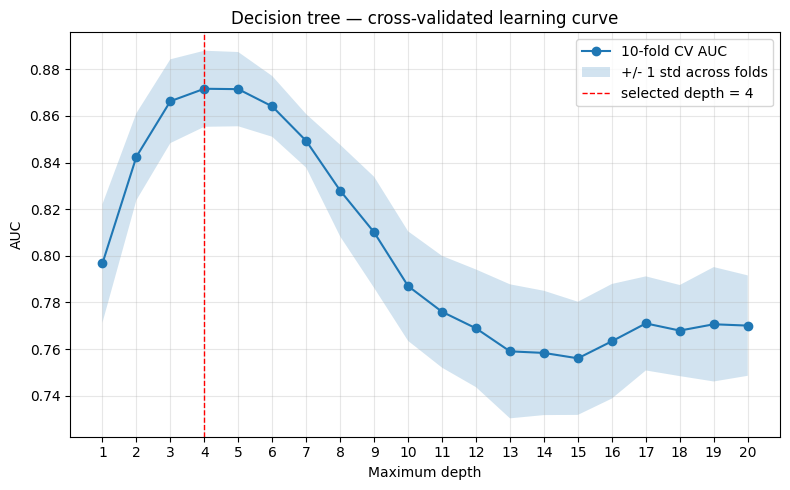

  [cache] loaded  cv_decision_tree
Decision Tree — 10-fold CV AUC = 0.8717 +/- 0.0163


In [47]:
# Cross-validated learning curve
plt.figure(figsize=(8, 5))
plt.plot(depth_values, depth_cv_mean, 'o-', label=f'{CV_FOLDS}-fold CV AUC')
plt.fill_between(depth_values, depth_cv_mean - depth_cv_std, depth_cv_mean + depth_cv_std,
                 alpha=0.2, label='+/- 1 std across folds')
plt.axvline(best_depth, color='red', linestyle='--', linewidth=1,
            label=f'selected depth = {best_depth}')
plt.xlabel('Maximum depth')
plt.ylabel('AUC')
plt.title('Decision tree — cross-validated learning curve')
plt.xticks(depth_values)
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / '16_dtree_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

make_tree = lambda: DecisionTreeClassifier(max_depth=best_depth, class_weight='balanced',
                                           random_state=RANDOM_STATE)
cv_scores['Decision Tree'] = cached('cv_decision_tree',
                                    lambda: cv_auc(make_tree, X_train),
                                    extra=best_depth)
print(f"Decision Tree — {CV_FOLDS}-fold CV AUC = "
      f"{cv_scores['Decision Tree'].mean():.4f} +/- {cv_scores['Decision Tree'].std():.4f}")


### 3.8 Baseline 3 — linear support vector machine

`LinearSVC` is the linear-kernel SVM. Unlike the other models it produces no probability, only a signed distance to the separating hyperplane; that margin is a perfectly valid ranking score and is what its AUC is computed from.


In [48]:
make_svc = lambda: scaled(LinearSVC(max_iter=5000, class_weight='balanced',
                                    random_state=RANDOM_STATE))

cv_scores['SVC'] = cached('cv_svc', lambda: cv_auc(make_svc, X_train))
print(f"SVC — {CV_FOLDS}-fold CV AUC = "
      f"{cv_scores['SVC'].mean():.4f} +/- {cv_scores['SVC'].std():.4f}")


  [cache] loaded  cv_svc
SVC — 10-fold CV AUC = 0.9145 +/- 0.0174


### 3.9 Hyper-parameter search for the three ensembles

All three boosters are searched over the **same 48-configuration grid**, with the **same selection criterion** — the mean AUC over the ten folds — so the comparison between them is fair.

> **Cost.** 48 configurations × 10 folds × 3 models is about 1,440 model fits and takes roughly half an hour. Setting `CV_FOLDS = 5` above halves it.

> **Selection bias, stated openly.** The configuration is chosen by the same cross-validation that reports its score, so the CV figure of the *winning* configuration is **slightly optimistic** — it is the maximum of 48 noisy estimates. That is the price of not spending a nested cross-validation on a 4,424-row dataset. It is also exactly why the holdout exists: the final numbers reported at the end come from 885 students that took no part in any of this, and those are unbiased.


In [49]:
def tune_by_cv(make_model, grid, name, X_src, fit_kwargs=None):
    """Pick hyper-parameters by mean AUC over the CV folds of the training pool.

    The search is the expensive part of the notebook, so its result is cached:
    the winning parameters AND the per-fold AUC array behind them.
    """
    def _search():
        combos = [dict(zip(grid.keys(), v)) for v in itertools.product(*grid.values())]
        best = {'auc': -1.0, 'params': None, 'folds': None}
        for p in tqdm(combos, desc=name):
            a = cv_auc(lambda p=p: make_model(p), X_src, fit_kwargs)
            if a.mean() > best['auc']:
                best = {'auc': float(a.mean()), 'params': p, 'folds': a}
        return best

    best = cached(f'tuning_{name.lower()}', _search, extra=grid)
    print(f"\n{name} — best parameters: {best['params']}")
    print(f"{name} — {CV_FOLDS}-fold CV AUC: {best['auc']:.4f} +/- {best['folds'].std():.4f}")
    cv_scores[name] = best['folds']
    return best

# The same 48-configuration search space for all three models
COMMON_GRID = {'learning_rate': [0.01, 0.05, 0.1],
               'n_estimators':  [50, 100, 150, 200],
               'max_depth':     [3, 5, 7, 10]}

best_lgb = tune_by_cv(
    lambda p: lgb.LGBMClassifier(objective='binary', is_unbalance=True,
                                 random_state=RANDOM_STATE, verbose=-1, **p),
    COMMON_GRID, 'LightGBM', X_train_df)


  [cache] loaded  tuning_lightgbm

LightGBM — best parameters: {'learning_rate': 0.1, 'n_estimators': 100, 'max_depth': 3}
LightGBM — 10-fold CV AUC: 0.9186 +/- 0.0122


**XGBoost.** `scale_pos_weight` plays the role of `is_unbalance`, and `enable_categorical=True` with `tree_method='hist'` lets it split the nominal variables on group membership the same way LightGBM does.

In [50]:
from xgboost import XGBClassifier

best_xgb = tune_by_cv(
    lambda p: XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                            scale_pos_weight=spw, enable_categorical=True,
                            tree_method='hist', random_state=RANDOM_STATE,
                            verbosity=0, **p),
    COMMON_GRID, 'XGBoost', X_train_df)


  [cache] loaded  tuning_xgboost

XGBoost — best parameters: {'learning_rate': 0.05, 'n_estimators': 200, 'max_depth': 3}
XGBoost — 10-fold CV AUC: 0.9183 +/- 0.0121


**CatBoost.** Uses ordered boosting, and applies ordered target statistics to the columns named in `cat_features`.

> **Implementation note.** `cat_features` is passed to **`fit()`**, not to the constructor. CatBoost mutates that argument internally, which breaks `sklearn.base.clone()` — and cloning is what every fold of the cross-validation relies on.


In [51]:
from catboost import CatBoostClassifier, Pool

CAT_GRID = {'learning_rate': COMMON_GRID['learning_rate'],
            'iterations':    COMMON_GRID['n_estimators'],
            'depth':         [3, 5, 7, 10]}

best_cat = tune_by_cv(
    lambda p: CatBoostClassifier(loss_function='Logloss', auto_class_weights='Balanced',
                                 random_seed=RANDOM_STATE, verbose=0,
                                 allow_writing_files=False, **p),
    CAT_GRID, 'CatBoost', X_train_cb,
    fit_kwargs={'cat_features': CATEGORICAL_COLS})


  [cache] loaded  tuning_catboost

CatBoost — best parameters: {'learning_rate': 0.05, 'iterations': 150, 'depth': 10}
CatBoost — 10-fold CV AUC: 0.9174 +/- 0.0135


### 3.10 Cross-validation results — the comparison that counts

This is the table the thesis should quote when comparing models. Three columns matter:

- **CV mean AUC** — the central estimate, averaged over ten independently held-out folds.
- **CV std** — how much the score moves from fold to fold. When this is as large as the gap between two models, those two models are **not distinguishable** on this dataset.
- **Std error** = std / √10 — the uncertainty of the *mean* itself.


10-fold stratified cross-validation on the 3539-student training pool:


,Model,CV mean AUC,CV std,Std error,CV min,CV max
0,LightGBM,0.9186,0.0122,0.0039,0.8979,0.9434
1,XGBoost,0.9183,0.0121,0.0038,0.8976,0.9403
2,CatBoost,0.9174,0.0135,0.0043,0.9001,0.9445
3,SVC,0.9145,0.0174,0.0055,0.8872,0.9510
4,Logistic Regression,0.9140,0.0172,0.0055,0.8856,0.9494
5,Decision Tree,0.8717,0.0163,0.0052,0.8397,0.8983


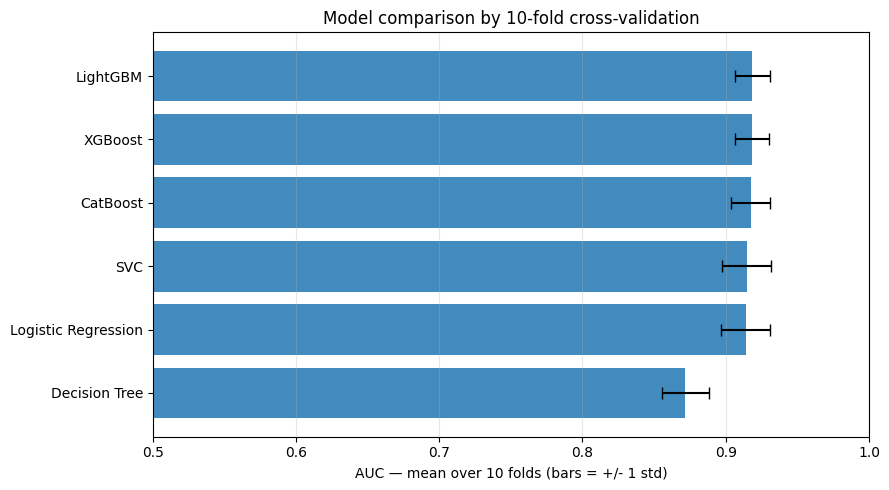

5 of 6 models fall within one fold-to-fold standard deviation of the best: LightGBM, XGBoost, CatBoost, SVC, Logistic Regression
Best model by cross-validation: LightGBM


In [52]:
cv_summary = (pd.DataFrame([
        {'Model': n,
         'CV mean AUC': round(float(v.mean()), 4),
         'CV std':      round(float(v.std()), 4),
         'Std error':   round(float(v.std() / np.sqrt(len(v))), 4),
         'CV min':      round(float(v.min()), 4),
         'CV max':      round(float(v.max()), 4)}
        for n, v in cv_scores.items()])
    .sort_values('CV mean AUC', ascending=False).reset_index(drop=True))

print(f'{CV_FOLDS}-fold stratified cross-validation on the {len(X_train)}-student training pool:')
display(cv_summary)

order = cv_summary['Model'][::-1]
plt.figure(figsize=(9, 5))
plt.barh(order, cv_summary.set_index('Model').loc[order, 'CV mean AUC'],
         xerr=cv_summary.set_index('Model').loc[order, 'CV std'],
         capsize=4, alpha=0.85)
plt.xlim(0.5, 1.0)
plt.xlabel(f'AUC — mean over {CV_FOLDS} folds (bars = +/- 1 std)')
plt.title(f'Model comparison by {CV_FOLDS}-fold cross-validation')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / '27_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

lead = cv_summary[cv_summary['CV mean AUC'] >=
                  cv_summary['CV mean AUC'].max() - cv_summary['CV std'].max()]
print(f'{len(lead)} of {len(cv_summary)} models fall within one fold-to-fold standard '
      f'deviation of the best: {", ".join(lead["Model"])}')
best_cv_model = cv_summary.iloc[0]['Model']
print(f'Best model by cross-validation: {best_cv_model}')


### 3.11 Final evaluation on the sealed holdout

Every model is now refitted on the **whole 3,539-student training pool** — the ten fold-models were only ever a measuring device — and scored **once** on the 885 holdout students.

These numbers carry no selection bias: the holdout took no part in the encoding, the scaling, the depth search or the 48-configuration grid.

Six metrics are reported, because accuracy alone hides what matters here:

| Metric | What it answers |
|---|---|
| Accuracy | Share of all students classified correctly — reference only; a constant answer already scores 67,9% |
| **AUC** | Given one dropout and one non-dropout, how often is the dropout ranked riskier? |
| **AP** | Area under the precision–recall curve — the honest counterpart of AUC for a minority class |
| **Recall** | Of the students who really dropped out, how many did the model flag? **The metric an early-warning system exists to maximise** |
| Precision | Of the students flagged, how many really dropped out? Every false alarm costs counselling time |
| F1 | Harmonic mean of the two, at the 0.5 threshold |


In [53]:
# ---------------------------------------------------------------------------
# Refit on the FULL training pool, then score once on the sealed holdout.
# ---------------------------------------------------------------------------
FINAL_MODELS = {
    'Logistic Regression': (make_lr,  X_train,    X_test,    {}),
    'Decision Tree':       (make_tree, X_train,   X_test,    {}),
    'SVC':                 (make_svc, X_train,    X_test,    {}),
    'LightGBM': (lambda: lgb.LGBMClassifier(objective='binary', is_unbalance=True,
                                            random_state=RANDOM_STATE, verbose=-1,
                                            **best_lgb['params']),
                 X_train_df, X_test_df, {}),
    'XGBoost':  (lambda: XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                                       scale_pos_weight=spw, enable_categorical=True,
                                       tree_method='hist', random_state=RANDOM_STATE,
                                       verbosity=0, **best_xgb['params']),
                 X_train_df, X_test_df, {}),
    'CatBoost': (lambda: CatBoostClassifier(loss_function='Logloss',
                                            auto_class_weights='Balanced',
                                            random_seed=RANDOM_STATE, verbose=0,
                                            allow_writing_files=False, **best_cat['params']),
                 X_train_cb, X_test_cb, {'cat_features': CATEGORICAL_COLS}),
}

def _fit_final():
    out = {}
    for name, (build, X_fit, _, fkw) in FINAL_MODELS.items():
        m = build()
        m.fit(X_fit, y_train, **fkw)
        out[name] = m
        print(f'    fitted {name:22s} on {len(X_fit)} students')
    return out

# The fitted models are stored too, so the SHAP and sensitivity sections below
# can run without refitting anything.
fitted_models = cached('final_models', _fit_final,
                       extra=(best_lgb['params'], best_xgb['params'],
                              best_cat['params'], best_depth))

results = {}
for name, (_, _, X_eval, _) in FINAL_MODELS.items():
    m = fitted_models[name]
    results[name] = (y_test,
                     np.asarray(m.predict(X_eval)).ravel(),
                     risk_score(m, X_eval))

list_of_models = list(FINAL_MODELS)
trained_models = [fitted_models[n] for n in list_of_models]
dictionary_models = dict(zip(list_of_models, trained_models))

lr_fitted, tree_fitted, svm_fitted = (fitted_models['Logistic Regression'],
                                      fitted_models['Decision Tree'],
                                      fitted_models['SVC'])
best_lgb_model = fitted_models['LightGBM']
best_xgb_model = fitted_models['XGBoost']
best_cat_model = fitted_models['CatBoost']

summary = (pd.DataFrame([
        {'Model':     n,
         'Accuracy':  round(accuracy_score(yt, yp), 4),
         'AUC':       round(roc_auc_score(yt, ys), 4),
         'AP':        round(average_precision_score(yt, ys), 4),
         'Recall':    round(recall_score(yt, yp), 4),
         'Precision': round(precision_score(yt, yp), 4),
         'F1':        round(f1_score(yt, yp), 4)}
        for n, (yt, yp, ys) in results.items()])
    .sort_values('AUC', ascending=False).reset_index(drop=True))

lgb_auc = float(summary.set_index('Model').loc['LightGBM', 'AUC'])

print(f'\nHoldout performance — {len(y_test)} students never used for anything above:')
display(summary.merge(cv_summary[['Model', 'CV mean AUC']], on='Model')
        .rename(columns={'AUC': 'Holdout AUC'}))

for metric, scale in [('AUC', 'Blues'), ('Recall', 'Oranges')]:
    d = summary.sort_values(metric)
    fig = px.bar(d, x=metric, y='Model', orientation='h',
                 text=d[metric].round(4).astype(str),
                 color=metric, color_continuous_scale=scale, width=850, height=480)
    fig.update_traces(textposition='outside')
    fig.update_layout(title=f'Holdout {metric} (885 students)',
                      xaxis=dict(range=[0, 1.0]), coloraxis_showscale=False)
    save_fig(fig, f'03_model_comparison_{metric.lower()}')


  [cache] loaded  final_models



Holdout performance — 885 students never used for anything above:


,Model,Accuracy,Holdout AUC,AP,Recall,Precision,F1,CV mean AUC
0,LightGBM,0.8678,0.9323,0.9013,0.8310,0.7738,0.8014,0.9186
1,CatBoost,0.8678,0.9316,0.9026,0.7993,0.7909,0.7951,0.9174
2,XGBoost,0.8723,0.9304,0.9018,0.8345,0.7822,0.8075,0.9183
3,SVC,0.8768,0.9272,0.8948,0.8310,0.7946,0.8124,0.9145
4,Logistic Regression,0.8746,0.9269,0.8956,0.8310,0.7893,0.8096,0.9140
5,Decision Tree,0.8565,0.8994,0.8237,0.7993,0.7643,0.7814,0.8717


Highest holdout AUC: LightGBM  (AUC = 0.9323, accuracy = 0.8678)
Best by cross-validation was: LightGBM


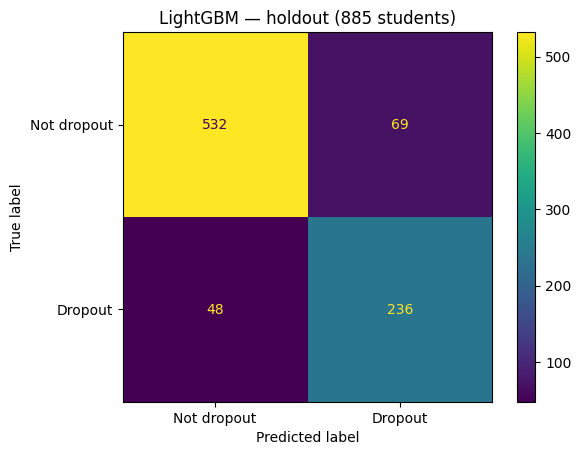

In [54]:
# ---------------------------------------------------------------------------
# The headline model, and its confusion matrix on the holdout.
# ---------------------------------------------------------------------------
key_best_model = summary.iloc[0]['Model']
best_auc       = summary.iloc[0]['AUC']
best_acc       = summary.iloc[0]['Accuracy']

print(f'Highest holdout AUC: {key_best_model}  (AUC = {best_auc}, accuracy = {best_acc})')
print(f'Best by cross-validation was: {best_cv_model}')
if key_best_model != best_cv_model:
    print('=> The two disagree. With five models inside one standard deviation of each '
          'other that is expected, and it is itself evidence that the ranking is noise.')

y_true, y_pred, y_score = results[key_best_model]
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Not dropout', 'Dropout'])
disp.plot()
plt.title(f'{key_best_model} — holdout ({len(y_test)} students)')
plt.savefig(FIG_DIR / '17_confusion_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

other_models = [n for n in summary['Model'] if n != key_best_model]


#### Confusion matrix for the other classifiers

The confusion matrices below cover **every remaining model**, in descending order of AUC. The bottom-right cell is the number of at-risk students the model correctly identified — the quantity an early-warning system exists to maximise.


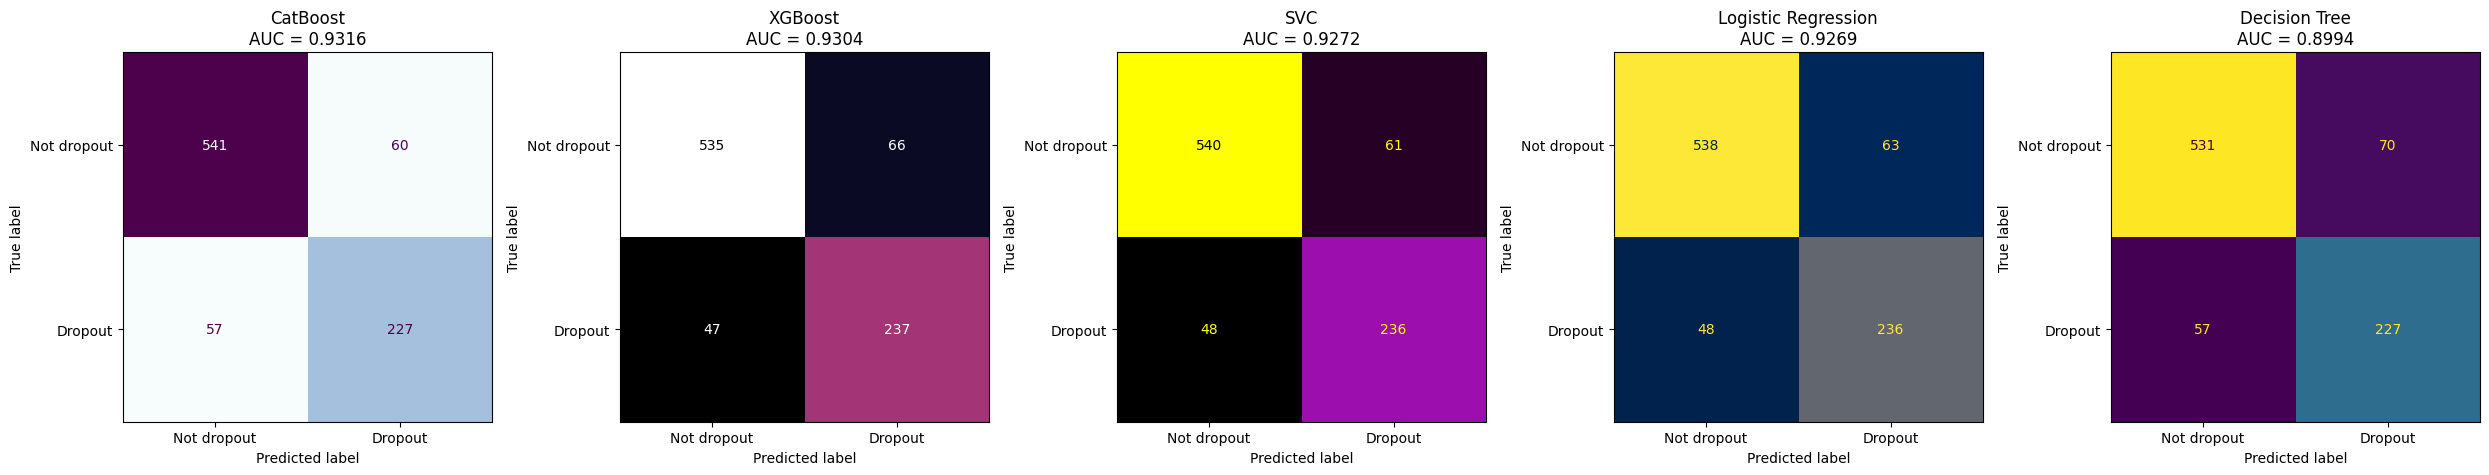

In [55]:
colors = ['BuPu', 'CMRmap', 'gnuplot', 'cividis', 'viridis']

fig, ax = plt.subplots(1, len(other_models), figsize=(5 * len(other_models), 5))
axes = np.atleast_1d(ax)

for position, name in enumerate(other_models):
    y_true, y_pred, _ = results[name]
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Not dropout', 'Dropout'])
    disp.plot(cmap=colors[position % len(colors)], ax=axes[position], colorbar=False)
    axes[position].set_title(f"{name}\nAUC = {summary.set_index('Model').loc[name, 'AUC']}")

plt.tight_layout()  # Adjust spacing between subplots
plt.savefig(FIG_DIR / '18_confusion_other_models.png', dpi=150, bbox_inches='tight')
plt.show()


In [56]:
# The leading group = every model within 0.01 AUC of the best.
lead = summary[summary['AUC'] >= summary['AUC'].max() - 0.01]
behind = summary[~summary['Model'].isin(lead['Model'])]
spread = lead['AUC'].max() - lead['AUC'].min()

msg = (f"#### On the test set **{key_best_model}** has the highest AUC "
       f"(**{best_auc:.4f}**), with an accuracy of **{best_acc * 100:.2f}%**.\n\n"
       f"**{len(lead)} of the {len(summary)} models sit within {spread:.4f} AUC of each other** "
       f"({', '.join(lead['Model'])}). On a test set of {len(y_test)} students that gap is "
       f"smaller than the sampling error, so the ranking between them must **not** be read as "
       f"one algorithm being decisively better than another. The cross-validation below, and the "
       f"split-variation experiment after it, quantify exactly how little it means.\n\n"
       f"All six models are now weighted for the class imbalance in the same way, so the "
       f"comparison is like-for-like. In particular the three baselines are **not** behind on "
       f"recall: logistic regression reaches "
       f"{summary.set_index('Model').loc['Logistic Regression', 'Recall']:.3f} against "
       f"{summary.set_index('Model').loc['LightGBM', 'Recall']:.3f} for LightGBM.")

if len(behind):
    worst = behind.iloc[-1]
    msg += (f"\n\nOnly **{worst['Model']}** is clearly behind (AUC {worst['AUC']:.4f}); its depth "
            f"of {best_depth} levels was selected on accuracy rather than AUC.")

Markdown(msg)


#### On the test set **LightGBM** has the highest AUC (**0.9323**), with an accuracy of **86.78%**.

**5 of the 6 models sit within 0.0054 AUC of each other** (LightGBM, CatBoost, XGBoost, SVC, Logistic Regression). On a test set of 885 students that gap is smaller than the sampling error, so the ranking between them must **not** be read as one algorithm being decisively better than another. The cross-validation below, and the split-variation experiment after it, quantify exactly how little it means.

All six models are now weighted for the class imbalance in the same way, so the comparison is like-for-like. In particular the three baselines are **not** behind on recall: logistic regression reaches 0.831 against 0.831 for LightGBM.

Only **Decision Tree** is clearly behind (AUC 0.8994); its depth of 4 levels was selected on accuracy rather than AUC.

### 3.12 Limitation — how the baselines see the categorical variables

One asymmetry remains in the table above, and it is stated here rather than engineered away.

The three baselines receive the eight nominal variables as **standardised numbers**. `Course` is coded 33 … 9991, so a linear model reads Nursing (9500) as a larger *quantity* than Agronomy (9003) and fits a single coefficient to that ordering. It is the same mis-specification the boosting models were explicitly protected from by declaring those columns `category`.

The textbook remedy is one-hot encoding. The cell below measures what that would cost on this dataset.


In [57]:
# What one-hot encoding the eight nominal variables would cost.
onehot_cost = pd.DataFrame([
    {'variable': c, 'levels': len(_levels[c]), 'one-hot columns': len(_levels[c]) - 1}
    for c in CATEGORICAL_COLS
]).sort_values('levels', ascending=False)

extra = onehot_cost['one-hot columns'].sum()
after = len(feature_columns) - len(CATEGORICAL_COLS) + extra

display(onehot_cost)
print(f'Feature count: {len(feature_columns)} -> {after}  '
      f'({after / len(feature_columns):.1f}x) on {len(X_train)} training rows')
print(f'Rows per feature: {len(X_train) / len(feature_columns):.0f} -> {len(X_train) / after:.0f}')


,variable,levels,one-hot columns
7,Father's occupation,46,45
5,Father's qualification,34,33
6,Mother's occupation,32,31
4,Mother's qualification,29,28
1,Application mode,18,17
2,Course,17,16
3,Previous qualification,17,16
0,Marital status,6,5


Feature count: 32 -> 215  (6.7x) on 3539 training rows
Rows per feature: 111 -> 16


#### Why the limitation is accepted rather than fixed

**This is the point the thesis is making, not a problem it is hiding.**

The difficulty of representing categorical variables *is* the classical models' weakness. One-hot encoding trades one mis-specification for another: it multiplies the feature count several times over on a training set of fewer than 3,000 students, so each new column is estimated from a handful of rows, and a rare occupation code becomes a near-empty column that a linear model will happily overfit. Neither version of the baseline is "the right one" — that is precisely the difficulty.

LightGBM removes the choice. It splits on **group membership** directly, needs no expansion, and keeps the feature named `Course` intact — which is what allows the SHAP section below to report *"this student's programme raised their risk"* instead of *"dummy variable 137 raised their risk"*.

So the comparison table should be read as: **the models are equivalent on discrimination**, and the baselines reach that level *despite* an encoding that misrepresents eight of their thirty-two inputs. The argument for LightGBM in this study is not a decimal place of AUC — it is that it handles this data type natively and stays explainable, which is what the second half of the title requires.

> **To state in Chương 3 (Hạn chế).** The baseline models treat the nominal codes as ordered quantities. One-hot encoding was considered and not applied, so as to keep a single preprocessing pipeline for all six models and to avoid inflating the feature space on a small sample. The consequence is that the baseline scores are a **lower bound** on what those models could achieve with a dedicated encoding — which does not affect the conclusions, since the study does not claim LightGBM is the more accurate model.


---

## 4. How much of the score is luck?

Cross-validation answers *which model*. It does not answer *how much of the holdout score is luck*, and that question matters because the holdout is one draw of 885 students.

The cell below settles it empirically: the same LightGBM, with the same hyper-parameters, refitted on **20 different stratified splits** of the same 4,424 students. Only the split changes.


  [cache] loaded  split_variation


,Splits tried,Mean AUC,Std,Min,Max,Range,AUC reported above,Its percentile
0,20,0.9184,0.0094,0.8927,0.9304,0.0377,0.9323,100%


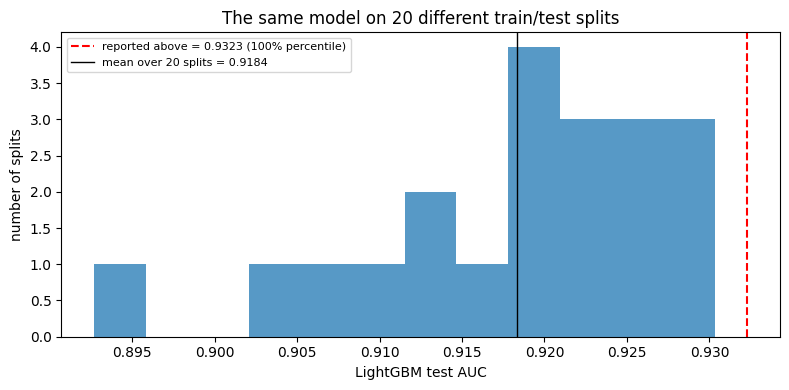

One split moves the AUC by up to 0.0377 — far more than the gap between any two models in the comparison table.


In [58]:
# The same model, the same hyper-parameters — only the train/test split changes.
def _split_variation():
    out = []
    for seed in tqdm(range(20), desc='split seeds'):
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2,
                                              random_state=seed, stratify=y)
        m = lgb.LGBMClassifier(objective='binary', is_unbalance=True,
                               random_state=RANDOM_STATE, verbose=-1, **best_lgb['params'])
        m.fit(to_categorical_df(Xtr), ytr)
        out.append(roc_auc_score(yte, m.predict_proba(to_categorical_df(Xte))[:, 1]))
    return np.array(out)

split_aucs = cached('split_variation', _split_variation, extra=best_lgb['params'])
reported = summary.set_index('Model').loc['LightGBM', 'AUC']
pct = (split_aucs < reported).mean()

split_variation = pd.DataFrame([{
    'Splits tried': len(split_aucs),
    'Mean AUC':  round(float(split_aucs.mean()), 4),
    'Std':       round(float(split_aucs.std()), 4),
    'Min':       round(float(split_aucs.min()), 4),
    'Max':       round(float(split_aucs.max()), 4),
    'Range':     round(float(split_aucs.max() - split_aucs.min()), 4),
    'AUC reported above': reported,
    'Its percentile': f'{pct:.0%}',
}])
display(split_variation)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(split_aucs, bins=12, alpha=0.75)
ax.axvline(reported, color='red', linestyle='--', linewidth=1.5,
           label=f'reported above = {reported:.4f} ({pct:.0%} percentile)')
ax.axvline(split_aucs.mean(), color='black', linestyle='-', linewidth=1,
           label=f'mean over 20 splits = {split_aucs.mean():.4f}')
ax.set_xlabel('LightGBM test AUC')
ax.set_ylabel('number of splits')
ax.set_title('The same model on 20 different train/test splits')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / '26_split_variation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'One split moves the AUC by up to {split_aucs.max() - split_aucs.min():.4f} — '
      f'far more than the gap between any two models in the comparison table.')


### 4.1 What this means for the thesis

The spread across splits is **larger than the spread across models**. Two consequences follow, and both belong in Chương 3.

**Quote the cross-validated figure, not the single-split one.** The test-set table is kept because it shows precision, recall and the confusion matrix on data the model never saw, but the AUC it reports is one draw from a distribution roughly 0.05 wide. The mean over 20 splits is the honest central estimate.

**Never rank models on a single split.** The whole six-model table spans less AUC than one model spans across splits. Any sentence of the form "model X is better than model Y" needs the cross-validation table behind it, and even there the fold-to-fold standard deviation has to be quoted alongside.


---

## 5. Reading the model — threshold, feature importance, ROC

An early-warning system is judged by how many at-risk students it actually reaches. That is **recall**, and recall depends on the probability threshold at which a student is flagged — 0.5 by default, but there is nothing special about 0.5.

The table below sweeps the threshold for the model with the best AUC and shows the trade-off explicitly: a lower threshold flags more students (higher recall) at the cost of more false alarms (lower precision).


=== LightGBM — classification report at the default threshold ===
              precision    recall  f1-score   support

 Not dropout      0.917     0.885     0.901       601
     Dropout      0.774     0.831     0.801       284

    accuracy                          0.868       885
   macro avg      0.846     0.858     0.851       885
weighted avg      0.871     0.868     0.869       885

Threshold sweep uses: LightGBM
Threshold sweep — LightGBM · test set = 885 students, 284 of whom dropped out


,Threshold,Flagged,Recall,Precision,F1,Accuracy
0,0.2,479,0.930,0.551,0.692,0.734
1,0.3,387,0.912,0.669,0.772,0.827
2,0.4,340,0.873,0.729,0.795,0.855
3,0.5,305,0.831,0.774,0.801,0.868
4,0.6,275,0.796,0.822,0.809,0.879
5,0.7,230,0.715,0.883,0.790,0.878
6,0.8,203,0.644,0.901,0.752,0.863


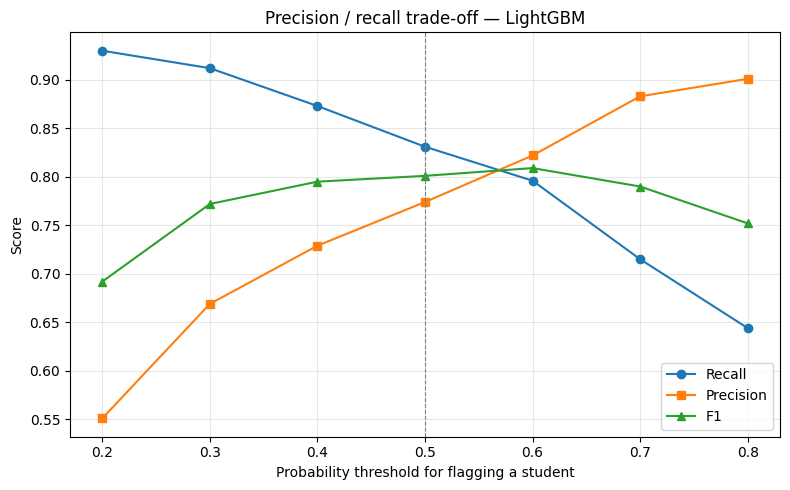

In [59]:
# Classification report at the default threshold, then a threshold sweep.
y_true_b, y_pred_b, y_score_b = results[key_best_model]

print(f'=== {key_best_model} — classification report at the default threshold ===')
print(classification_report(y_true_b, y_pred_b,
                            target_names=['Not dropout', 'Dropout'], digits=3))

# The sweep needs a probability; LinearSVC only produces a margin, so fall back
# to the best model that does produce one.
sweep_name = key_best_model if hasattr(
    dict(zip(list_of_models, trained_models))[key_best_model], 'predict_proba') else 'LightGBM'
_, _, sweep_score = results[sweep_name]
sweep_true = y_test
print(f'Threshold sweep uses: {sweep_name}')

rows = []
for thr in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    yp = (sweep_score >= thr).astype(int)
    rows.append({'Threshold': thr,
                 'Flagged': int(yp.sum()),
                 'Recall':    round(recall_score(sweep_true, yp, zero_division=0), 3),
                 'Precision': round(precision_score(sweep_true, yp, zero_division=0), 3),
                 'F1':        round(f1_score(sweep_true, yp, zero_division=0), 3),
                 'Accuracy':  round(accuracy_score(sweep_true, yp), 3)})
threshold_table = pd.DataFrame(rows)

print(f'Threshold sweep — {sweep_name} · test set = {len(sweep_true)} students, '
      f'{int(sweep_true.sum())} of whom dropped out')
display(threshold_table)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(threshold_table['Threshold'], threshold_table['Recall'], 'o-', label='Recall')
ax.plot(threshold_table['Threshold'], threshold_table['Precision'], 's-', label='Precision')
ax.plot(threshold_table['Threshold'], threshold_table['F1'], '^-', label='F1')
ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Probability threshold for flagging a student')
ax.set_ylabel('Score')
ax.set_title(f'Precision / recall trade-off — {sweep_name}')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_threshold_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.2 Feature importance — which variables each model leans on

Every model can report which features it used most. The six numbers are on six
incompatible scales, so the table below reports the **rank** of each feature
within each model, which is the only comparable quantity.


In [60]:
# Extract feature importance from EACH model
# (this is the step the supervisor asked for, to identify the causes of dropout)
models_dict = dict(zip(list_of_models, trained_models))

def unwrap(model):
    """Reach the estimator inside a Pipeline; return it unchanged otherwise."""
    return model.named_steps['clf'] if hasattr(model, 'named_steps') else model

importances = {}
for name in ['Logistic Regression', 'SVC']:
    # |coefficient| on STANDARDISED inputs — the scaler lives inside the Pipeline
    importances[name] = pd.Series(np.abs(unwrap(models_dict[name]).coef_).ravel(),
                                  index=feature_columns).sort_values()
for name in ['Decision Tree', 'LightGBM', 'XGBoost', 'CatBoost']:
    importances[name] = pd.Series(unwrap(models_dict[name]).feature_importances_,
                                  index=feature_columns).sort_values()

# ---------------------------------------------------------------------------
# The six numbers are NOT on the same scale and must not be compared directly:
#   LightGBM  -> number of splits that used the feature
#   XGBoost   -> average gain per split
#   CatBoost  -> PredictionValuesChange (%)
#   DecisionTree -> share of the total impurity reduction
#   LogReg / SVC -> |coefficient| on STANDARDISED inputs
# What IS comparable is the ORDER.
# ---------------------------------------------------------------------------
rank_table = pd.DataFrame({name: s.rank(ascending=False, method='min').astype(int)
                           for name, s in importances.items()})
rank_table['Mean rank'] = rank_table.mean(axis=1).round(1)
rank_table = rank_table.sort_values('Mean rank')

print('Feature importance RANK per model (1 = most important), sorted by average rank:')
display(rank_table.head(15))

for name, s in importances.items():
    print(f"\n--- {name}: top 5 most important features ---")
    print(s.sort_values(ascending=False).head(5).to_string())


Feature importance RANK per model (1 = most important), sorted by average rank:


,Logistic Regression,SVC,Decision Tree,LightGBM,XGBoost,CatBoost,Mean rank
Curricular units 2nd sem (approved),1,1,1,1,1,1,1.0
Tuition fees up to date,4,4,2,3,2,3,3.0
Age at enrollment,6,6,5,4,7,5,5.5
Curricular units 1st sem (approved),3,3,12,6,3,6,5.5
Curricular units 2nd sem (enrolled),2,2,3,16,12,12,7.8
Course,10,15,12,2,8,2,8.2
Curricular units 2nd sem (grade),8,14,8,9,4,9,8.7
Mother's occupation,7,8,9,11,15,16,11.0
Curricular units 1st sem (grade),9,9,11,8,22,11,11.7
Curricular units 2nd sem (credited),5,5,4,19,11,27,11.8



--- Logistic Regression: top 5 most important features ---
Curricular units 2nd sem (approved)    1.801161
Curricular units 2nd sem (enrolled)    0.889901
Curricular units 1st sem (approved)    0.853258
Tuition fees up to date                0.694040
Curricular units 2nd sem (credited)    0.459839

--- SVC: top 5 most important features ---
Curricular units 2nd sem (approved)    0.653314
Curricular units 2nd sem (enrolled)    0.349172
Curricular units 1st sem (approved)    0.287043
Tuition fees up to date                0.244399
Curricular units 2nd sem (credited)    0.149178

--- Decision Tree: top 5 most important features ---
Curricular units 2nd sem (approved)    0.741366
Tuition fees up to date                0.137851
Curricular units 2nd sem (enrolled)    0.043073
Curricular units 2nd sem (credited)    0.021279
Age at enrollment                      0.014653

--- LightGBM: top 5 most important features ---
Curricular units 2nd sem (approved)    72
Course                         

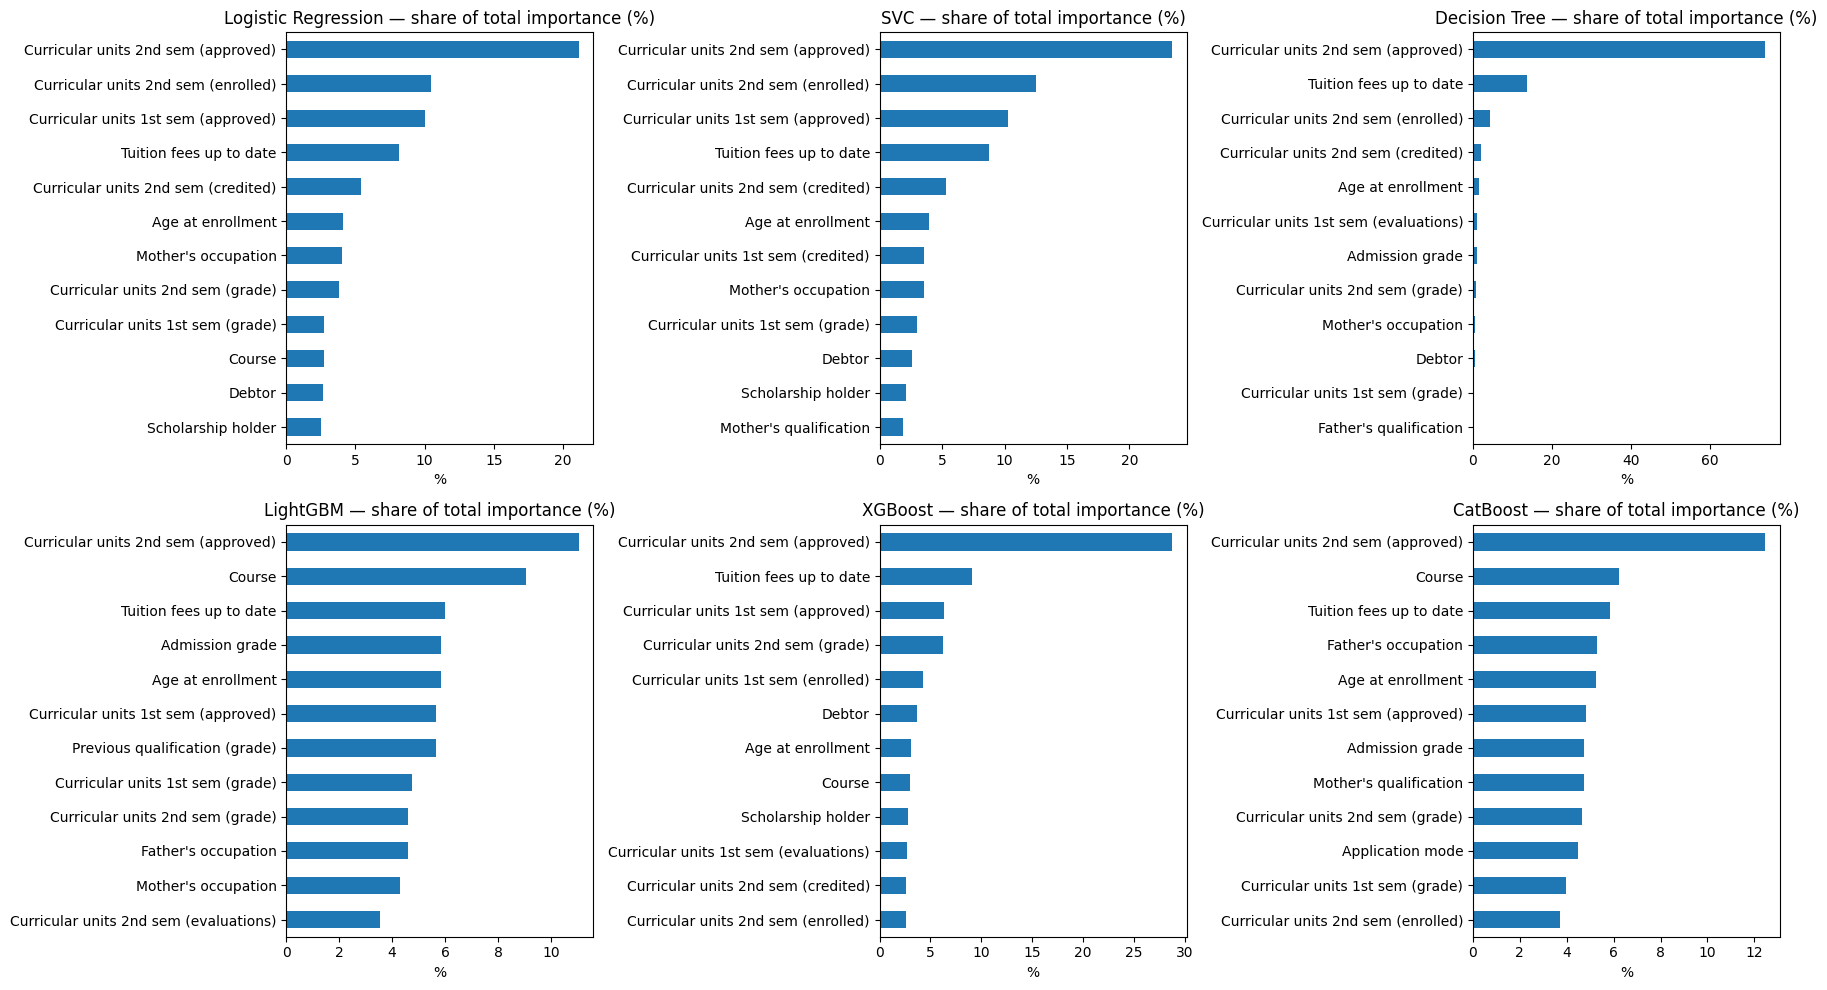

In [61]:
# Plot feature importance for every model — each normalised to a SHARE of its
# own total, so the six panels can be read side by side despite the different
# native units.
n = len(importances)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, ax = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(ax).reshape(-1)

for a, (name, s) in zip(axes, importances.items()):
    share = (s / s.sum() * 100)
    share.tail(12).plot(kind='barh', ax=a, title=f'{name} — share of total importance (%)')
    a.set_xlabel('%')

for a in axes[n:]:
    a.axis('off')

plt.tight_layout()
plt.savefig(FIG_DIR / '04_feature_importance_all_models.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.3 Reading the importance ranks

Read the **ranks**, not the raw numbers. The six models report importance on six different scales — number of splits (LightGBM), average gain (XGBoost), prediction-value change (CatBoost), impurity reduction (decision tree) and absolute coefficient on standardised inputs (logistic regression, linear SVM). A LightGBM value of 231 and a decision-tree value of 0.82 are simply not the same quantity, so the earlier claim that "all models agree" could not be checked from those columns.

What the rank table does show is genuine agreement on the **order**: the **number of curricular units passed** (especially in semester 2) and the **tuition payment status** occupy the top places in every model, linear and tree-based alike.

The agreement between very different model families is itself informative — it suggests the signal is in the data rather than an artefact of one particular algorithm.

Two limits still apply, and are the reason the SHAP section below exists:

1. Impurity- and split-based importances are **biased towards high-cardinality features** — a variable with many distinct values simply offers more places to split. That is exactly why `Course` and `Admission grade` climb the LightGBM list.
2. None of these numbers say whether a feature pushes the risk **up or down**, and none of them can explain an **individual student**.


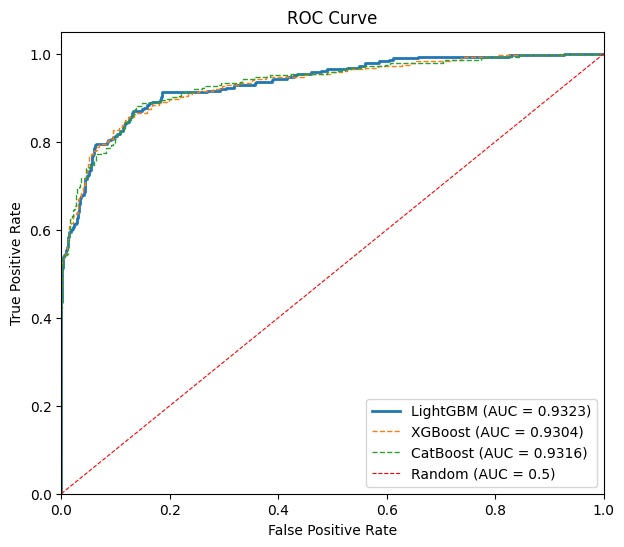


The AUC score is: 0.9323


In [62]:
# ROC curve of the best model, plus the three ensembles for comparison
y_true, _, y_score = results[key_best_model]
fpr, tpr, threshold = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'{key_best_model} (AUC = {roc_auc:.4f})')

for name in ['LightGBM', 'XGBoost', 'CatBoost']:
    if name == key_best_model:
        continue
    yt, _, ys = results[name]
    f, t, _ = roc_curve(yt, ys)
    plt.plot(f, t, linewidth=1, linestyle='--', label=f'{name} (AUC = {auc(f, t):.4f})')

plt.plot([0, 1], [0, 1], 'r--', linewidth=0.8, label='Random (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.savefig(FIG_DIR / '19_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nThe AUC score is: {round(roc_auc, 4)}')


### 5.4 Reading the ROC curve

The AUC is computed from the **predicted probabilities** (`predict_proba`), not from the hard 0/1 labels. Using hard labels would collapse the curve to a single operating point and understate the AUC.

An AUC of around 0.90 means that, given one student who dropped out and one who did not, the model ranks the dropout as the riskier of the two about 90% of the time.

---

## 6. SHAP — finding the causes of dropout

Feature importance shows *which* features matter, but not whether a feature pushes the risk **up or down**, and it cannot explain an **individual student**.

SHAP (SHapley Additive exPlanations) answers both. For tree models, `TreeExplainer` computes the values exactly and quickly.

Three levels of analysis follow:

| Level | Plot | Question answered |
|---|---|---|
| Global | `summary_plot(plot_type='bar')` | Which factors matter most across all students? |
| Global, with direction | `summary_plot` (beeswarm) | Does a high or low value of that factor **increase **the risk? |
| Individual | `waterfall` | Why is **this particular student **predicted to be at risk? |

> **How to phrase the findings. **SHAP describes the **behaviour of the model**, it does not prove causation. The results are therefore reported as **associated risk factors**, not as proven causes.

In [63]:
import shap

ensemble_models = {'LightGBM': best_lgb_model,
                   'XGBoost':  best_xgb_model,
                   'CatBoost': best_cat_model}

shap_values_all, shap_tables = {}, {}

for name, model in ensemble_models.items():
    explainer = shap.TreeExplainer(model)
    if name == 'CatBoost':
        sv = explainer.shap_values(Pool(X_test_cb, y_test, cat_features=CATEGORICAL_COLS))
    else:
        sv = explainer.shap_values(X_test_df)
    if isinstance(sv, list):          # some versions return [class 0, class 1]
        sv = sv[1]
    sv = np.array(sv)
    shap_values_all[name] = (explainer, sv)

    shap_tables[name] = (pd.DataFrame({'feature': feature_columns,
                                       'mean_abs_shap': np.abs(sv).mean(axis=0)})
                         .sort_values('mean_abs_shap', ascending=False)
                         .reset_index(drop=True))

print('SHAP values computed for:', ', '.join(shap_values_all))
print(f'SHAP matrix shape: {sv.shape} (students × features)')
print('\nThe plots below use X_test_disp — the features in their ORIGINAL units '
      '(age in years, number of units passed), not standardised values, so the '
      'risk factors can be acted on.')


/Users/macvn/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray



SHAP values computed for: LightGBM, XGBoost, CatBoost
SHAP matrix shape: (885, 32) (students × features)

The plots below use X_test_disp — the features in their ORIGINAL units (age in years, number of units passed), not standardised values, so the risk factors can be acted on.


### 6.1 Global — which factors matter most

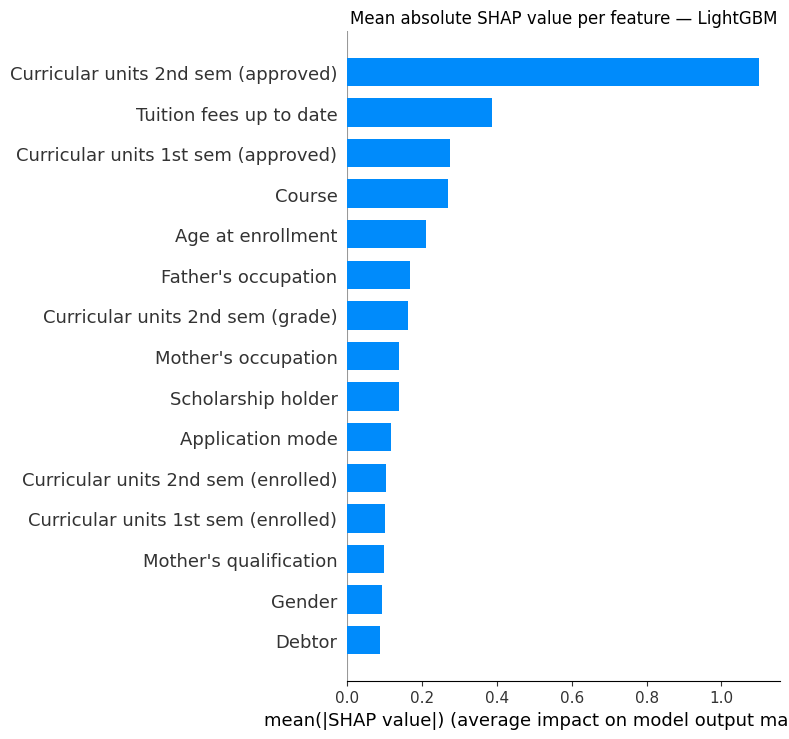

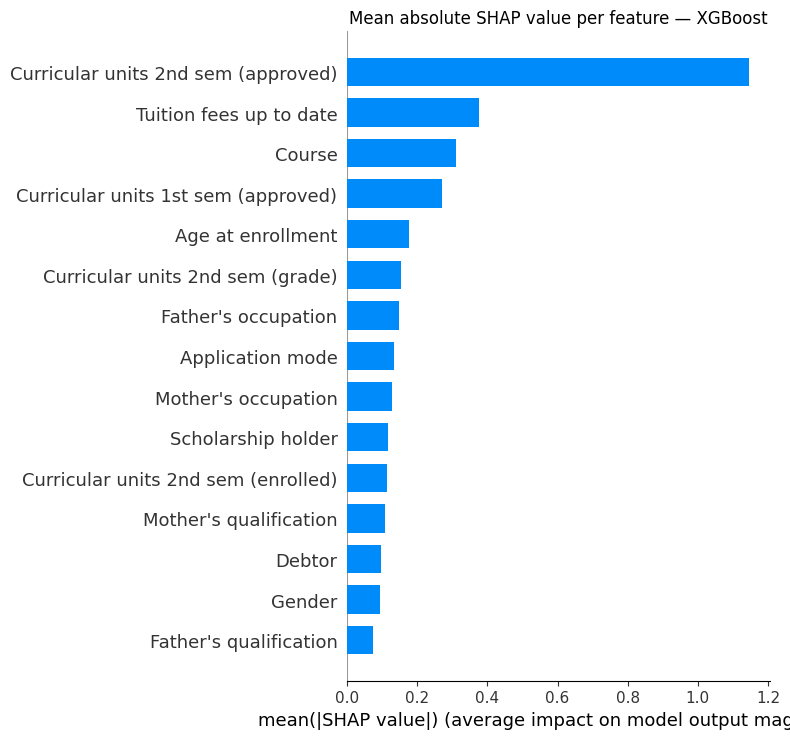

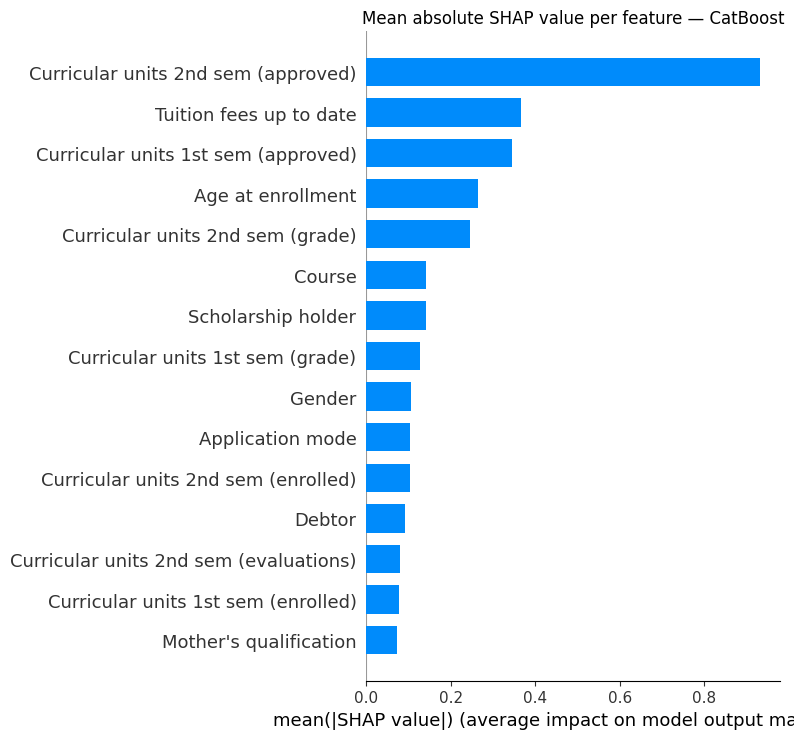

In [64]:
for name, (explainer, sv) in shap_values_all.items():
    shap.summary_plot(sv, X_test_disp, plot_type='bar', max_display=15, show=False)
    plt.title(f'Mean absolute SHAP value per feature — {name}')
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'20_shap_bar_{name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()


### 6.2 Global with direction — the beeswarm plot

How to read it: each dot is one student. The horizontal axis is the contribution to the prediction — **further right means pushed towards "dropout"**. Colour is the value of the feature: **red = high, blue = low**.

For example, if `Tuition fees up to date` shows **blue dots on the right**, that means **unpaid tuition (a low value) increases the dropout risk**.

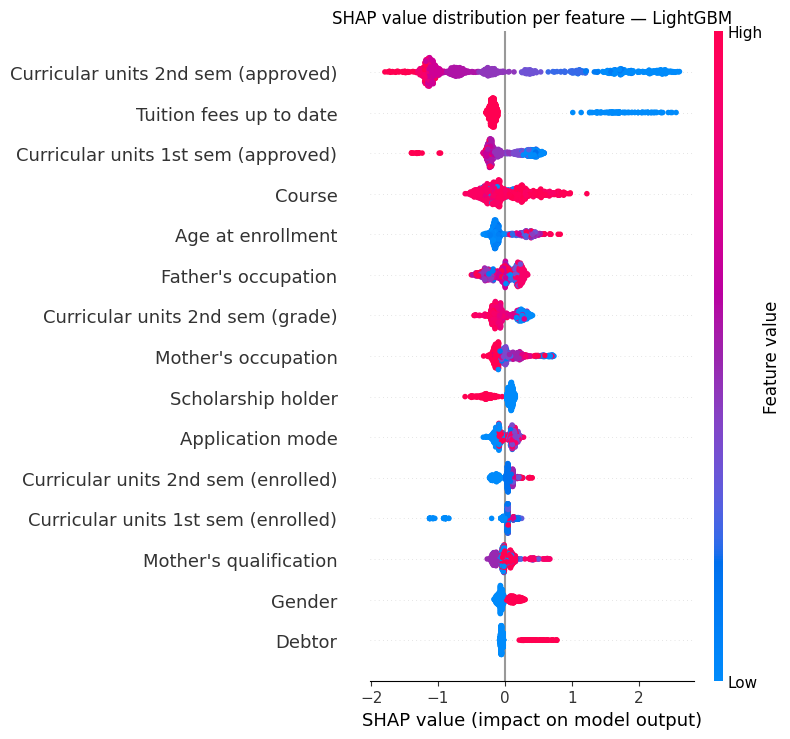

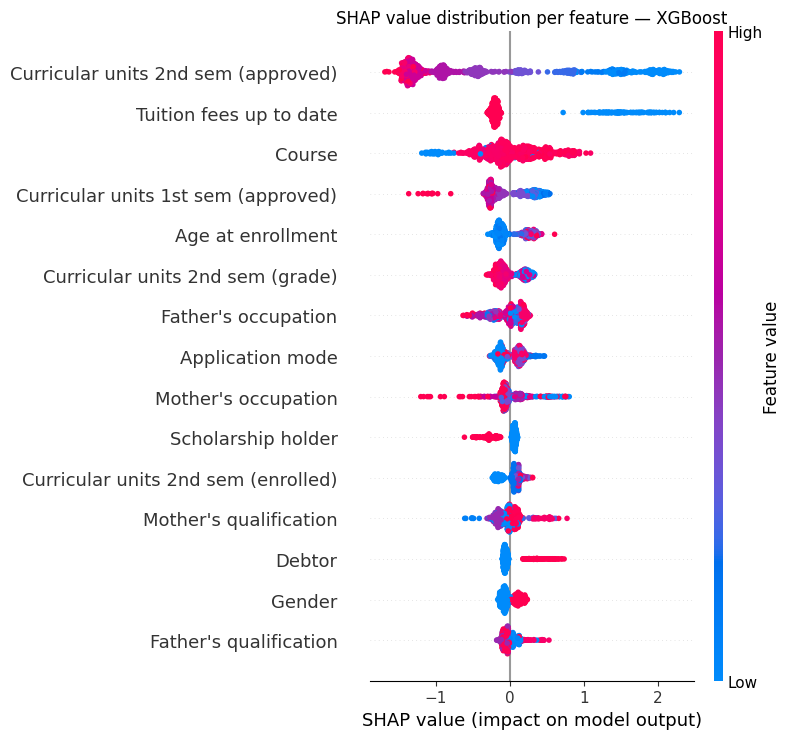

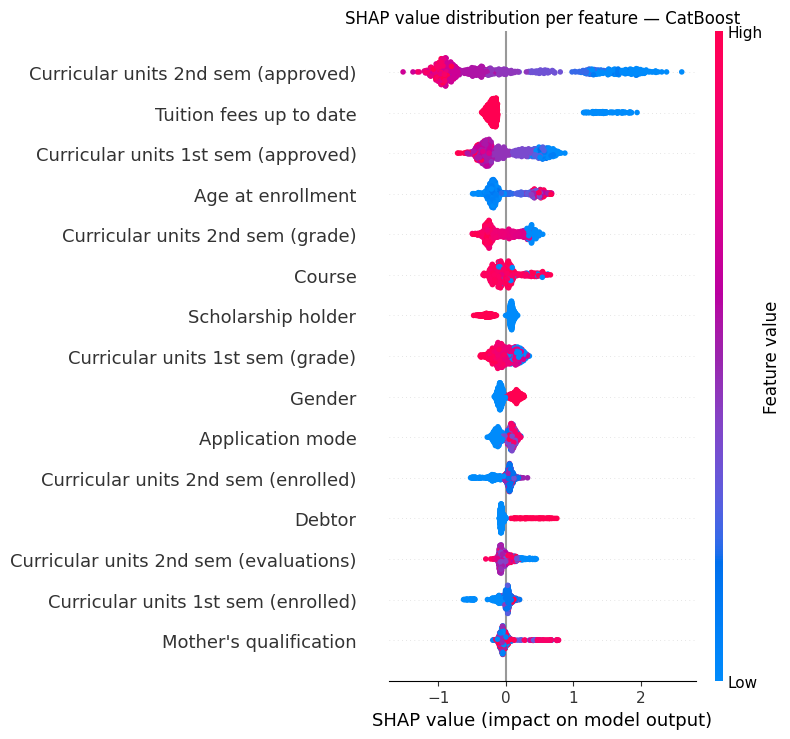

In [65]:
for name, (explainer, sv) in shap_values_all.items():
    shap.summary_plot(sv, X_test_disp, max_display=15, show=False)
    plt.title(f'SHAP value distribution per feature — {name}')
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'21_shap_beeswarm_{name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()


### 6.3 Individual — why is this student at risk

The waterfall plot decomposes the prediction for **one student** into the contribution of each feature:

- **E[f(x)]** is the average risk across the dataset (the base value).
- **Red** bars are factors that **increase** that student's dropout risk.
- **Blue** bars are factors that **decrease** it (they keep the student enrolled).

This is exactly what an academic advisor needs: not just "this student is at risk", but **where the risk comes from**, so the right kind of support can be offered.

Illustrated student: index 680 · predicted dropout probability = 99.7% · actual label = Dropout


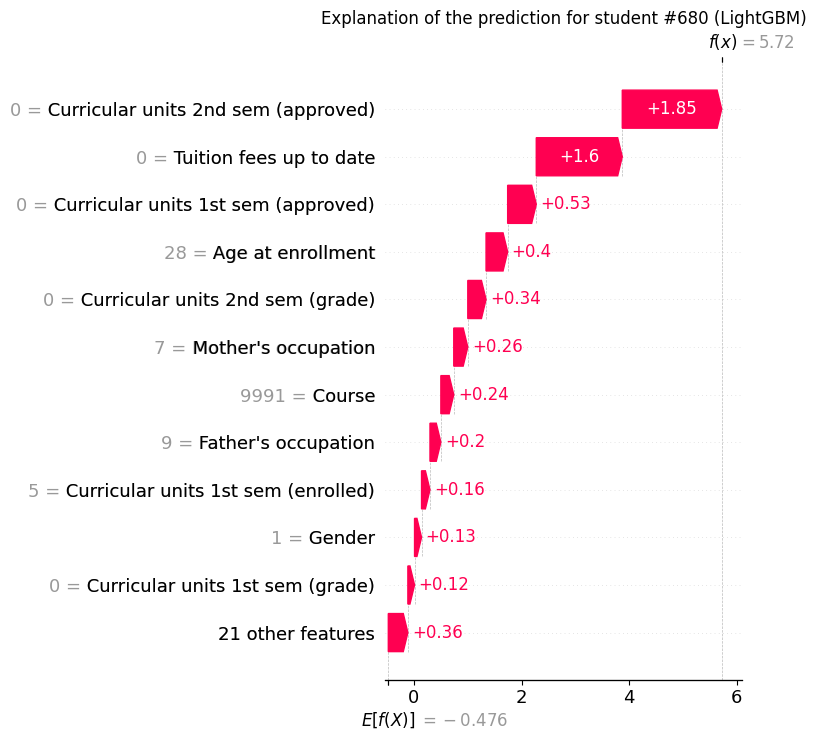


The same student, in the original units:
feature
Curricular units 2nd sem (approved)       0.0
Tuition fees up to date                   0.0
Curricular units 1st sem (approved)       0.0
Course                                 9991.0
Age at enrollment                        28.0
Father's occupation                       9.0
Curricular units 2nd sem (grade)          0.0
Mother's occupation                       7.0


In [66]:
# Pick the highest-risk student in the test set as the illustration
risk = best_lgb_model.predict_proba(X_test_df)[:, 1]
student_index = int(np.argmax(risk))
print(f'Illustrated student: index {student_index} · '
      f'predicted dropout probability = {risk[student_index]:.1%} · '
      f'actual label = {"Dropout" if y_test[student_index] == 1 else "Not dropout"}')

explainer, sv = shap_values_all['LightGBM']
base = explainer.expected_value
if isinstance(base, (list, np.ndarray)) and np.ndim(base) > 0:
    base = base[-1]

shap.plots.waterfall(
    shap.Explanation(values=sv[student_index],
                     base_values=float(base),
                     data=X_test_disp.iloc[student_index],   # ORIGINAL units
                     feature_names=feature_columns),
    max_display=12, show=False)
plt.title(f'Explanation of the prediction for student #{student_index} (LightGBM)')
plt.tight_layout()
plt.savefig(FIG_DIR / '22_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nThe same student, in the original units:')
print(X_test_disp.iloc[student_index]
      .reindex(shap_tables['LightGBM'].head(8)['feature']).to_string())


### 6.4 Summary of the risk factors

In [67]:
# Table of the top 10 risk factors according to each ensemble model
top = pd.DataFrame({name: t.head(10)['feature'].values
                    for name, t in shap_tables.items()},
                   index=[f'{i+1}' for i in range(10)])
print('Top 10 risk factors according to each model:')
display(top)

print('\nMean SHAP values (LightGBM):')
display(shap_tables['LightGBM'].head(10).round(4))

# Features in the top 10 of ALL THREE models — the stable set, safe to interpret
common = set(shap_tables['LightGBM'].head(10)['feature'])
for name in ['XGBoost', 'CatBoost']:
    common &= set(shap_tables[name].head(10)['feature'])
print(f'\nFactors in the top 10 of ALL THREE models ({len(common)}):')
for f in sorted(common):
    print(f'  - {f}')

Top 10 risk factors according to each model:


,LightGBM,XGBoost,CatBoost
1,Curricular units 2nd sem (approved),Curricular units 2nd sem (approved),Curricular units 2nd sem (approved)
2,Tuition fees up to date,Tuition fees up to date,Tuition fees up to date
3,Curricular units 1st sem (approved),Course,Curricular units 1st sem (approved)
4,Course,Curricular units 1st sem (approved),Age at enrollment
5,Age at enrollment,Age at enrollment,Curricular units 2nd sem (grade)
6,Father's occupation,Curricular units 2nd sem (grade),Course
7,Curricular units 2nd sem (grade),Father's occupation,Scholarship holder
8,Mother's occupation,Application mode,Curricular units 1st sem (grade)
9,Scholarship holder,Mother's occupation,Gender
10,Application mode,Scholarship holder,Application mode



Mean SHAP values (LightGBM):


,feature,mean_abs_shap
0,Curricular units 2nd sem (approved),1.1014
1,Tuition fees up to date,0.3862
2,Curricular units 1st sem (approved),0.2737
3,Course,0.2698
4,Age at enrollment,0.2116
5,Father's occupation,0.1674
6,Curricular units 2nd sem (grade),0.1628
7,Mother's occupation,0.1397
8,Scholarship holder,0.1385
9,Application mode,0.1180



Factors in the top 10 of ALL THREE models (8):
  - Age at enrollment
  - Application mode
  - Course
  - Curricular units 1st sem (approved)
  - Curricular units 2nd sem (approved)
  - Curricular units 2nd sem (grade)
  - Scholarship holder
  - Tuition fees up to date


---

## 7. Sensitivity — does the answer depend on the `Enrolled` students?

The 794 `Enrolled` students were labelled 0 ("not dropout"), because at the observation date they had not left. The label is a **snapshot**: some of them may leave later, which would make them mislabelled in hindsight.

The check below removes them entirely — from training and from testing — and refits LightGBM with the same hyper-parameters on the remaining `Dropout` vs `Graduate` students. If the AUC and the leading risk factors survive, the conclusions of this study do not rest on that labelling choice.


In [68]:
# Refit on Dropout vs Graduate only, dropping every 'Enrolled' student.
tr_keep = enr_train == 0
te_keep = enr_test  == 0

X_tr_ne, y_tr_ne = X_train_df[tr_keep], y_train[tr_keep]
X_te_ne, y_te_ne = X_test_df[te_keep],  y_test[te_keep]

print(f'Training: {len(y_train)} -> {len(y_tr_ne)} students '
      f'(dropout {y_train.mean():.1%} -> {y_tr_ne.mean():.1%})')
print(f'Test    : {len(y_test)} -> {len(y_te_ne)} students '
      f'(dropout {y_test.mean():.1%} -> {y_te_ne.mean():.1%})')

lgb_ne = lgb.LGBMClassifier(objective='binary', is_unbalance=True,
                            random_state=RANDOM_STATE, verbose=-1, **best_lgb['params'])
lgb_ne.fit(X_tr_ne, y_tr_ne)

auc_ne = roc_auc_score(y_te_ne, lgb_ne.predict_proba(X_te_ne)[:, 1])
rec_ne = recall_score(y_te_ne, lgb_ne.predict(X_te_ne))

sv_ne = shap.TreeExplainer(lgb_ne).shap_values(X_te_ne)
if isinstance(sv_ne, list):
    sv_ne = sv_ne[1]
top_ne = (pd.DataFrame({'feature': feature_columns,
                        'mean_abs_shap': np.abs(np.array(sv_ne)).mean(axis=0)})
          .sort_values('mean_abs_shap', ascending=False).reset_index(drop=True))

top_all = shap_tables['LightGBM'].head(10)['feature'].tolist()
top_drop = top_ne.head(10)['feature'].tolist()
overlap = len(set(top_all) & set(top_drop))

sensitivity = pd.DataFrame([
    {'Variant': 'Enrolled kept as 0 (main analysis)',
     'Train n': len(y_train), 'Test n': len(y_test),
     'AUC': round(lgb_auc, 4),
     'Recall': round(summary.set_index('Model').loc['LightGBM', 'Recall'], 4)},
    {'Variant': 'Enrolled removed (Dropout vs Graduate)',
     'Train n': int(tr_keep.sum()), 'Test n': int(te_keep.sum()),
     'AUC': round(float(auc_ne), 4),
     'Recall': round(float(rec_ne), 4)},
])
display(sensitivity)

print(f'Risk factors shared by the top 10 of both variants: {overlap}/10')
print('\nTop 10 — Enrolled removed:')
for i, f in enumerate(top_drop, 1):
    mark = '' if f in top_all else '   <- new'
    print(f'  {i:2d}. {f}{mark}')


Training: 3539 -> 2907 students (dropout 32.1% -> 39.1%)
Test    : 885 -> 723 students (dropout 32.1% -> 39.3%)


/Users/macvn/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray



,Variant,Train n,Test n,AUC,Recall
0,Enrolled kept as 0 (main analysis),3539,885,0.9323,0.8310
1,Enrolled removed (Dropout vs Graduate),2907,723,0.9624,0.8697


Risk factors shared by the top 10 of both variants: 8/10

Top 10 — Enrolled removed:
   1. Curricular units 2nd sem (approved)
   2. Curricular units 1st sem (approved)
   3. Tuition fees up to date
   4. Curricular units 2nd sem (grade)
   5. Course
   6. Curricular units 1st sem (enrolled)   <- new
   7. Scholarship holder
   8. Age at enrollment
   9. Debtor   <- new
  10. Application mode


### 7.1 Reading the sensitivity analysis

Two numbers matter.

**The AUC of the two variants.** Removing the `Enrolled` students makes the problem *easier* — the two remaining groups are the clearest cases — so a higher AUC here is expected and is **not** evidence that the main model is better. What would be worrying is a *drop*, which would mean the main model was relying on the `Enrolled` group to reach its score.

**The overlap between the two lists of risk factors.** This is the result that carries into the conclusions: if the same factors lead in both variants, the causes reported by this study do not depend on how the `Enrolled` students were labelled.


---

## 8. External validation — 7,523 Vietnamese students

Everything up to this point was measured on one Portuguese institution. This section asks the question the thesis actually needs to answer: **does any of it hold for students in Vietnam?**

`Testkhoa.csv` is a registry extract supplied by the supervisor: **7,523 students, 33 columns, four enrolment years (2020–2023)**, with a `Drop` label. It is not a benchmark — it is real administrative data from a real faculty, and it is the only genuinely *external* test available to this study.

Two experiments run here, and they answer different questions:

| | Question | Model |
|---|---|---|
| **Experiment 1 — transfer** | Does a model trained on Portuguese students rank Vietnamese students correctly? | the LightGBM fitted earlier, unchanged |
| **Experiment 2 — replication** | Does the *pipeline* work on this data, and are the risk factors the same? | a new LightGBM fitted on Testkhoa itself |

Neither replaces the other. Experiment 1 tests whether the *knowledge* transfers; experiment 2 tests whether the *method* does.


In [69]:
# ---------------------------------------------------------------------------
# 1. Load the registry extract.
#
# Encoding note: the file is read as latin-1. The Vietnamese diacritics were
# already destroyed when the file was exported — "Nữ" is stored as the literal
# bytes "N?" (0x4E 0x3F) — so no encoding can recover them. This is harmless
# for the columns used below (Gender has 2 values, Rating has 7) but it means
# the text labels cannot be printed correctly.
# ---------------------------------------------------------------------------
TESTKHOA_FILE = Path('Testkhoa.csv')
testkhoa_ready = TESTKHOA_FILE.exists()

if not testkhoa_ready:
    print(f'{TESTKHOA_FILE} not found — this section is skipped.')
else:
    vn = pd.read_csv(TESTKHOA_FILE, encoding='latin-1')
    y_vn = vn['Drop'].to_numpy()

    print(f'{len(vn):,} students · {len(vn.columns)} columns · '
          f'enrolment years {vn.EnrollmentYear.min()}–{vn.EnrollmentYear.max()}')
    print(f'\nDropout rate — Vietnam {y_vn.mean():.1%}  vs  Portugal (UCI) {y.mean():.1%}'
          f'   ({y.mean() / y_vn.mean():.1f}x higher in the UCI data)')
    print(vn['Drop'].value_counts().rename({0: 'stayed', 1: 'dropped out'}).to_string())


7,523 students · 33 columns · enrolment years 2020–2023

Dropout rate — Vietnam 13.2%  vs  Portugal (UCI) 32.1%   (2.4x higher in the UCI data)
Drop
stayed         6533
dropped out     990


### 8.1 Two columns that would silently destroy the experiment

Registry data records what happened, not only what was known at the time. Two groups of columns in this file are **consequences of dropping out rather than predictors of it**, and using them produces a model that looks perfect and predicts nothing.

The cell below measures both before deciding what to keep.


In [70]:
if testkhoa_ready:
    print('Correlation with the Drop label:')
    for c in ['TermStatus_1', 'TermStatus_2', 'TermStatus_3', 'TermStatus_4']:
        print(f'  {c:15s} r = {vn[c].corr(vn.Drop):+.3f}')

    print('\nShare of students whose GPA is exactly 0 — i.e. who registered for nothing:')
    print(f'  {"":10s} {"all":>8s} {"among Drop=1":>14s}')
    for c in ['GPA4_1', 'GPA4_2', 'GPA4_3', 'GPA4_4']:
        print(f'  {c:10s} {(vn[c] == 0).mean():8.1%} {(vn.loc[vn.Drop == 1, c] == 0).mean():14.1%}')

    # What each block of columns is worth, on its own, by 5-fold CV
    from sklearn.model_selection import cross_val_score
    def quick_auc(cols):
        Z = vn[cols].copy()
        for c in Z.columns:
            if Z[c].dtype == object:
                Z[c] = pd.Categorical(Z[c]).codes
        return cross_val_score(
            lgb.LGBMClassifier(objective='binary', is_unbalance=True,
                               random_state=RANDOM_STATE, verbose=-1),
            Z, y_vn, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
            scoring='roc_auc').mean()

    leak_probe = cached('testkhoa_leak_probe', lambda: {
        'TermStatus only':          quick_auc([f'TermStatus_{i}' for i in range(1, 5)]),
        'every column':             quick_auc([c for c in vn.columns
                                               if c not in ('StudentID', 'Drop')]),
        'terms 1-2, no TermStatus': quick_auc(['Gender', 'SumScore', 'IndustryCode',
                                               'Aspiration', 'Region', 'GPA4_1',
                                               'CreditsRegistered_1', 'CreditsEarnned_1',
                                               'GPA4_2', 'CreditsRegistered_2',
                                               'CreditsEarnned_2']),
        'term 1 only':              quick_auc(['GPA4_1', 'CreditsRegistered_1',
                                               'CreditsEarnned_1']),
    })
    print('\n5-fold CV AUC on Testkhoa, by which columns are allowed in:')
    for k, v in leak_probe.items():
        flag = '   <-- LEAKAGE' if v > 0.99 else ''
        print(f'  {k:28s} {v:.4f}{flag}')


Correlation with the Drop label:
  TermStatus_1    r = +0.490
  TermStatus_2    r = +0.790
  TermStatus_3    r = +0.844
  TermStatus_4    r = +0.841

Share of students whose GPA is exactly 0 — i.e. who registered for nothing:
                  all   among Drop=1
  GPA4_1         2.0%          14.6%
  GPA4_2         6.4%          47.5%
  GPA4_3         9.9%          73.1%
  GPA4_4        10.8%          76.9%
  [cache] loaded  testkhoa_leak_probe

5-fold CV AUC on Testkhoa, by which columns are allowed in:
  TermStatus only              1.0000   <-- LEAKAGE
  every column                 0.9999   <-- LEAKAGE
  terms 1-2, no TermStatus     0.9555
  term 1 only                  0.8134


### 8.2 What is excluded, and why

**`TermStatus_1…4` are dropped.** On their own they reach an AUC of **1.0000** — they are not correlated with the outcome, they *are* the outcome, recorded per term. Any model given these columns reports a perfect score that means nothing. Feeding the file in whole, as-is, produces 0.9999 for the same reason: it is the single easiest mistake to make with this dataset.

**Semesters 3 and 4 are dropped.** Among the students who left, **73% have a GPA of exactly 0 in semester 3 and 77% in semester 4** — not because they failed, but because they were no longer enrolled. Those zeros are a *record of the outcome*, written after it happened. Using them to predict the outcome is predicting the past from the future.

**What remains is semesters 1–2 plus the intake information**, which reaches **0.9555** honestly — and, conveniently, matches the two semesters the UCI dataset contains, so the same student is described the same way in both files.

> A model restricted to **semester 1 alone** still reaches **0.8134**. That is the operationally useful number: it is what the faculty could know at the end of the first semester, in time to do something about it.


### 8.3 Mapping the two schemas

Nine of the 32 features the model expects have a counterpart in the registry. The units differ in every case, so **renaming alone is not enough **— a grade of 2.31 on a 4-point scale is a good student, but the model learned that grades run 0–20 and would read it as near-failure.

| UCI feature (0–20, 0–26, 95–200) | Testkhoa column | Conversion |
|---|---|---|
| `Curricular units 1st/2nd sem (grade)` | `GPA4_1/2` (0–4) | `GPA4 / 4 × 20` |
| `Curricular units 1st/2nd sem (enrolled)` | `CreditsRegistered_1/2` (~17) | `credits / median × 6` |
| `Curricular units 1st/2nd sem (approved)` | `CreditsEarnned_1/2` | same scaling |
| `Admission grade` (95–200) | `SumScore` (0–30.7) | min–max rescale |
| `Gender` (1 = male) | `Gender` (`Nam` = male) | direct |
| `Course` | `IndustryCode` | **0 of 70 codes overlap **— left missing |

The remaining **23 features are left missing**, including the entire financial block (`Tuition fees up to date`, `Debtor`, `Scholarship holder`) which ranks **second **in the model's own SHAP table. LightGBM handles missing values natively, which is exactly the property this section relies on.


In [71]:
if testkhoa_ready:
    TAG = {1: '1st', 2: '2nd'}

    def build_transfer_frame(rescale):
        """Testkhoa rows expressed in the UCI feature space."""
        f = pd.DataFrame(index=vn.index, columns=feature_columns, dtype=float)
        f['Gender'] = (vn.Gender == 'Nam').astype(float)      # 'Nam' = male, as in UCI

        if rescale:
            s = vn.SumScore
            f['Admission grade'] = 95 + (s - s.min()) / (s.max() - s.min()) * (200 - 95)
            for n in (1, 2):
                reg = vn[f'CreditsRegistered_{n}']
                med = reg[reg > 0].median()
                f[f'Curricular units {TAG[n]} sem (enrolled)'] = reg / med * 6
                f[f'Curricular units {TAG[n]} sem (approved)'] = vn[f'CreditsEarnned_{n}'] / med * 6
                f[f'Curricular units {TAG[n]} sem (grade)']    = vn[f'GPA4_{n}'] / 4 * 20
        else:
            f['Admission grade'] = vn.SumScore
            f['Course'] = vn.IndustryCode                     # codes do not overlap at all
            for n in (1, 2):
                f[f'Curricular units {TAG[n]} sem (enrolled)'] = vn[f'CreditsRegistered_{n}']
                f[f'Curricular units {TAG[n]} sem (approved)'] = vn[f'CreditsEarnned_{n}']
                f[f'Curricular units {TAG[n]} sem (grade)']    = vn[f'GPA4_{n}']

        out = f.reindex(columns=feature_columns)
        for c in CATEGORICAL_COLS:
            out[c] = pd.Categorical(out[c].round().astype('Int64'), categories=_levels[c])
        return out

    vn_named   = build_transfer_frame(rescale=False)
    vn_rescaled = build_transfer_frame(rescale=True)

    filled = vn_rescaled.notna().any().sum()
    print(f'{filled} of {len(feature_columns)} features have a Vietnamese counterpart; '
          f'{len(feature_columns) - filled} are left missing.')
    print('\nRange seen in training vs range fed in (rescaled frame):')
    for c in ['Curricular units 1st sem (grade)', 'Curricular units 1st sem (enrolled)',
              'Admission grade']:
        print(f'  {c:38s} UCI {X_train[c].min():6.1f}-{X_train[c].max():6.1f}'
              f'   VN {vn_rescaled[c].min():6.1f}-{vn_rescaled[c].max():6.1f}')


8 of 32 features have a Vietnamese counterpart; 24 are left missing.

Range seen in training vs range fed in (rescaled frame):
  Curricular units 1st sem (grade)       UCI    0.0-  18.0   VN    0.0-  20.0
  Curricular units 1st sem (enrolled)    UCI    0.0-  26.0   VN    0.0-   7.0
  Admission grade                        UCI   95.0- 190.0   VN   95.0- 200.0


### 8.4 Experiment 1 — transfer: does the Portuguese model rank Vietnamese students?

The model is used exactly as it was fitted. Nothing is retrained; the Vietnamese students are simply pushed through it.

Two versions are scored, because the difference between them is the point: **renaming the columns without converting the units**, and **renaming plus converting**.


LightGBM trained on 3,539 Portuguese students, applied to 7,523 Vietnamese students it has never seen:


,Input,AUC,AP,Mean predicted risk,Actual dropout rate
0,renamed only,0.9006,0.7896,49.5%,13.2%
1,renamed + rescaled,0.9426,0.8312,54.5%,13.2%


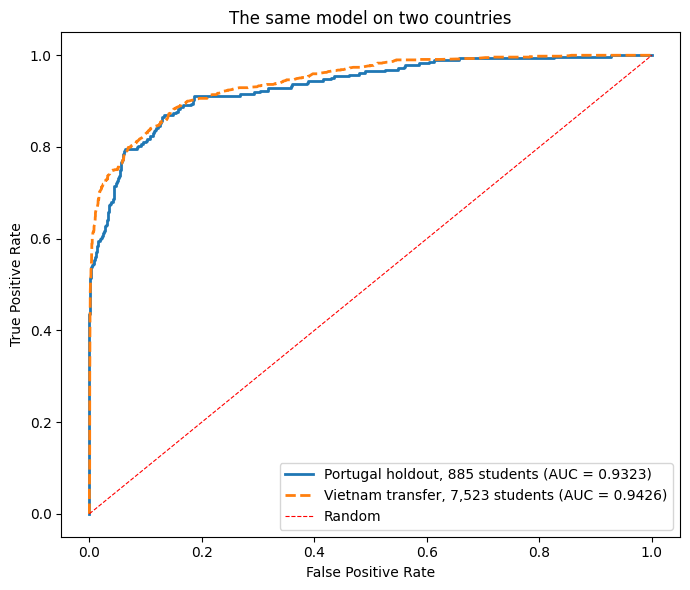

In [72]:
if testkhoa_ready:
    transfer_rows = []
    for label, frame in [('renamed only', vn_named), ('renamed + rescaled', vn_rescaled)]:
        p = best_lgb_model.predict_proba(frame)[:, 1]
        transfer_rows.append({
            'Input': label,
            'AUC':   round(roc_auc_score(y_vn, p), 4),
            'AP':    round(average_precision_score(y_vn, p), 4),
            'Mean predicted risk': f'{p.mean():.1%}',
            'Actual dropout rate': f'{y_vn.mean():.1%}',
        })
        if label == 'renamed + rescaled':
            p_transfer = p

    transfer_results = pd.DataFrame(transfer_rows)
    print('LightGBM trained on 3,539 Portuguese students, applied to '
          f'{len(vn):,} Vietnamese students it has never seen:')
    display(transfer_results)

    fpr_vn, tpr_vn, _ = roc_curve(y_vn, p_transfer)
    fpr_pt, tpr_pt, _ = roc_curve(*[results['LightGBM'][i] for i in (0, 2)])
    plt.figure(figsize=(7, 6))
    plt.plot(fpr_pt, tpr_pt, lw=2,
             label=f'Portugal holdout, 885 students (AUC = {auc(fpr_pt, tpr_pt):.4f})')
    plt.plot(fpr_vn, tpr_vn, lw=2, ls='--',
             label=f'Vietnam transfer, {len(vn):,} students (AUC = {auc(fpr_vn, tpr_vn):.4f})')
    plt.plot([0, 1], [0, 1], 'r--', lw=0.8, label='Random')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title('The same model on two countries')
    plt.legend(loc='lower right'); plt.tight_layout()
    plt.savefig(FIG_DIR / '28_transfer_roc.png', dpi=150, bbox_inches='tight')
    plt.show()


### 8.5 The probabilities do not transfer, even though the ranking does

AUC only asks whether at-risk students are ranked above the rest, and on that question the answer is yes. The **probability attached to each student is a different matter**: the model was calibrated on a population where 32,1% drop out, and it is being applied to one where 13,2% do. It therefore calls far too many students at risk at the default 0.5 threshold.

For an alert system that distinction is everything — the threshold has to be re-chosen for the new population. The sweep below shows what that costs and buys.


In [73]:
if testkhoa_ready:
    rows = []
    for thr in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
        yp = (p_transfer >= thr).astype(int)
        rows.append({'Threshold': thr,
                     'Flagged': int(yp.sum()),
                     'Flagged %': f'{yp.mean():.1%}',
                     'Recall':    round(recall_score(y_vn, yp, zero_division=0), 3),
                     'Precision': round(precision_score(y_vn, yp, zero_division=0), 3),
                     'F1':        round(f1_score(y_vn, yp, zero_division=0), 3)})
    transfer_thresholds = pd.DataFrame(rows)
    best_thr = transfer_thresholds.loc[transfer_thresholds['F1'].idxmax(), 'Threshold']

    print(f'Re-thresholding the transferred model for the Vietnamese base rate '
          f'({y_vn.mean():.1%} vs the 32.1% it was trained on):')
    display(transfer_thresholds)
    print(f'Best F1 at threshold {best_thr} — not 0.5. Choosing it needs labelled data '
          f'from the new institution, so in deployment it would be calibrated on one cohort '
          f'and applied to the next.')


Re-thresholding the transferred model for the Vietnamese base rate (13.2% vs the 32.1% it was trained on):


,Threshold,Flagged,Flagged %,Recall,Precision,F1
0,0.3,5764,76.6%,0.996,0.171,0.292
1,0.4,5481,72.9%,0.993,0.179,0.304
2,0.5,4590,61.0%,0.990,0.214,0.351
3,0.6,3396,45.1%,0.951,0.277,0.429
4,0.7,1832,24.4%,0.877,0.474,0.615
5,0.8,938,12.5%,0.733,0.774,0.753
6,0.9,553,7.4%,0.537,0.962,0.690


Best F1 at threshold 0.8 — not 0.5. Choosing it needs labelled data from the new institution, so in deployment it would be calibrated on one cohort and applied to the next.


### 8.6 Experiment 2 — replication: refitting the pipeline on Vietnamese data

The second question is whether the *method* survives the move, independently of the Portuguese model. A new LightGBM is fitted on Testkhoa itself, using the same protocol as the main analysis: stratified 10-fold cross-validation, `is_unbalance=True`, categorical columns declared as `category`, semesters 1–2 only.

The comparison that matters is not the AUC. It is whether **SHAP finds the same risk factors** in a different country, a different curriculum and a different administrative system.


  [cache] loaded  testkhoa_cv
  [cache] loaded  testkhoa_model
LightGBM refitted on Testkhoa · 10-fold CV AUC = 0.9543 +/- 0.0082   (19 features, 7,523 students)


/Users/macvn/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray



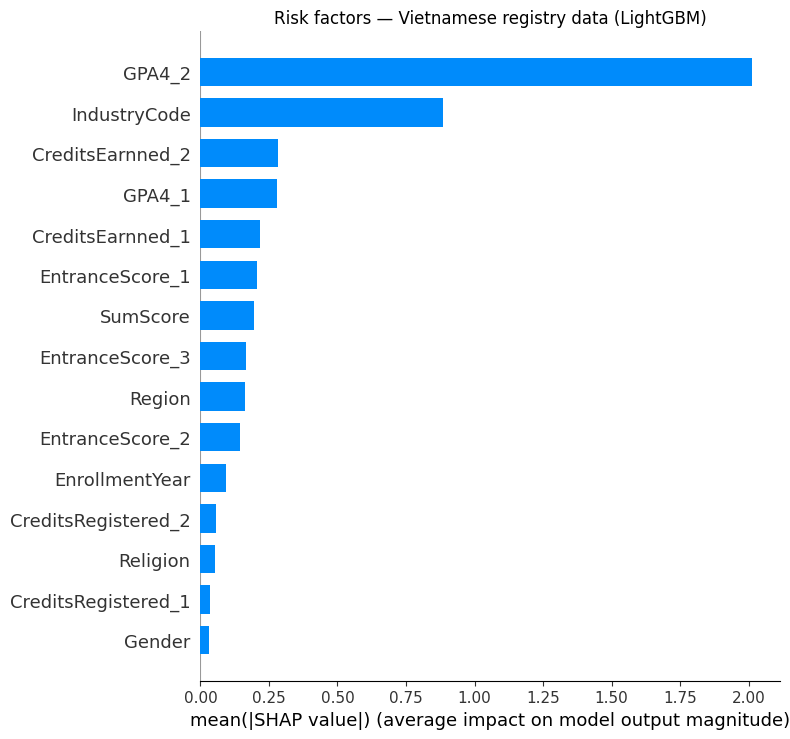

In [74]:
if testkhoa_ready:
    VN_CAT = ['Gender', 'Nation', 'Religion', 'Region', 'Aspiration',
              'IndustryCode', 'Rating_1', 'Rating_2', 'EnrollmentYear']
    VN_NUM = ['EntranceScore_1', 'EntranceScore_2', 'EntranceScore_3', 'SumScore',
              'GPA4_1', 'CreditsRegistered_1', 'CreditsEarnned_1',
              'GPA4_2', 'CreditsRegistered_2', 'CreditsEarnned_2']
    VN_FEATURES = VN_CAT + VN_NUM        # TermStatus and semesters 3-4 deliberately excluded

    X_vn = vn[VN_FEATURES].copy()
    for c in VN_CAT:
        X_vn[c] = pd.Categorical(X_vn[c])

    skf_vn = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    def _vn_cv():
        out = []
        for tr, va in skf_vn.split(X_vn, y_vn):
            m = lgb.LGBMClassifier(objective='binary', is_unbalance=True,
                                   random_state=RANDOM_STATE, verbose=-1)
            m.fit(X_vn.iloc[tr], y_vn[tr])
            out.append(roc_auc_score(y_vn[va], m.predict_proba(X_vn.iloc[va])[:, 1]))
        return np.array(out)

    vn_cv = cached('testkhoa_cv', _vn_cv, extra=tuple(VN_FEATURES))
    vn_model = cached('testkhoa_model',
                      lambda: lgb.LGBMClassifier(objective='binary', is_unbalance=True,
                                                 random_state=RANDOM_STATE, verbose=-1)
                                 .fit(X_vn, y_vn),
                      extra=tuple(VN_FEATURES))

    print(f'LightGBM refitted on Testkhoa · {CV_FOLDS}-fold CV AUC = '
          f'{vn_cv.mean():.4f} +/- {vn_cv.std():.4f}   ({len(VN_FEATURES)} features, '
          f'{len(X_vn):,} students)')

    sv_vn = shap.TreeExplainer(vn_model).shap_values(X_vn)
    if isinstance(sv_vn, list):
        sv_vn = sv_vn[1]
    shap_vn = (pd.DataFrame({'feature': VN_FEATURES,
                             'mean_abs_shap': np.abs(np.array(sv_vn)).mean(axis=0)})
               .sort_values('mean_abs_shap', ascending=False).reset_index(drop=True))

    shap.summary_plot(sv_vn, X_vn, plot_type='bar', max_display=15, show=False)
    plt.title('Risk factors — Vietnamese registry data (LightGBM)')
    plt.tight_layout()
    plt.savefig(FIG_DIR / '29_shap_testkhoa.png', dpi=150, bbox_inches='tight')
    plt.show()


In [75]:
if testkhoa_ready:
    # Do the two countries agree on WHAT drives dropout?
    THEME = {
        'Curricular units 2nd sem (approved)': 'credits passed',
        'Curricular units 1st sem (approved)': 'credits passed',
        'Curricular units 2nd sem (enrolled)': 'credits taken',
        'Curricular units 1st sem (enrolled)': 'credits taken',
        'Curricular units 2nd sem (grade)':    'grades',
        'Curricular units 1st sem (grade)':    'grades',
        'Tuition fees up to date': 'finance', 'Debtor': 'finance',
        'Scholarship holder': 'finance',
        'Admission grade': 'intake score', 'Course': 'programme',
        'Age at enrollment': 'demographics', 'Gender': 'demographics',
        'CreditsEarnned_1': 'credits passed', 'CreditsEarnned_2': 'credits passed',
        'CreditsRegistered_1': 'credits taken', 'CreditsRegistered_2': 'credits taken',
        'GPA4_1': 'grades', 'GPA4_2': 'grades', 'Rating_1': 'grades', 'Rating_2': 'grades',
        'SumScore': 'intake score', 'EntranceScore_1': 'intake score',
        'EntranceScore_2': 'intake score', 'EntranceScore_3': 'intake score',
        'IndustryCode': 'programme', 'Aspiration': 'programme',
        'Region': 'demographics', 'Nation': 'demographics', 'Religion': 'demographics',
        'EnrollmentYear': 'cohort',
    }
    pt_top = shap_tables['LightGBM'].head(10)['feature'].tolist()
    vn_top = shap_vn.head(10)['feature'].tolist()

    side = pd.DataFrame({
        'Rank': range(1, 11),
        'Portugal (UCI)': pt_top,
        'theme (PT)':     [THEME.get(f, '-') for f in pt_top],
        'Vietnam (Testkhoa)': vn_top,
        'theme (VN)':     [THEME.get(f, '-') for f in vn_top],
    }).set_index('Rank')
    print('Top 10 risk factors, side by side:')
    display(side)

    pt_themes = [THEME.get(f, '-') for f in pt_top]
    vn_themes = [THEME.get(f, '-') for f in vn_top]
    theme_cmp = (pd.DataFrame({'Portugal': pd.Series(pt_themes).value_counts(),
                               'Vietnam':  pd.Series(vn_themes).value_counts()})
                 .fillna(0).astype(int).sort_values('Portugal', ascending=False))
    print('\nHow many of each theme appear in the top 10:')
    display(theme_cmp)

    testkhoa_summary = pd.DataFrame([
        {'Experiment': 'Transfer — UCI model applied to Testkhoa',
         'n': len(vn), 'AUC': transfer_results.set_index('Input').loc['renamed + rescaled', 'AUC'],
         'Note': f'{filled}/{len(feature_columns)} features available, no retraining'},
        {'Experiment': 'Transfer — renamed but not rescaled',
         'n': len(vn), 'AUC': transfer_results.set_index('Input').loc['renamed only', 'AUC'],
         'Note': 'shows renaming alone is not enough'},
        {'Experiment': f'Replication — LightGBM refitted on Testkhoa ({CV_FOLDS}-fold CV)',
         'n': len(vn), 'AUC': round(float(vn_cv.mean()), 4),
         'Note': f'+/- {vn_cv.std():.4f}, {len(VN_FEATURES)} Vietnamese features'},
        {'Experiment': 'Reference — LightGBM on the Portuguese holdout',
         'n': len(y_test), 'AUC': float(summary.set_index('Model').loc['LightGBM', 'AUC']),
         'Note': 'same model, home data'},
    ])
    display(testkhoa_summary)


Top 10 risk factors, side by side:


,Portugal (UCI),theme (PT),Vietnam (Testkhoa),theme (VN)
Rank,,,,
1,Curricular units 2nd sem (approved),credits passed,GPA4_2,grades
2,Tuition fees up to date,finance,IndustryCode,programme
3,Curricular units 1st sem (approved),credits passed,CreditsEarnned_2,credits passed
4,Course,programme,GPA4_1,grades
5,Age at enrollment,demographics,CreditsEarnned_1,credits passed
6,Father's occupation,-,EntranceScore_1,intake score
7,Curricular units 2nd sem (grade),grades,SumScore,intake score
8,Mother's occupation,-,EntranceScore_3,intake score
9,Scholarship holder,finance,Region,demographics



How many of each theme appear in the top 10:


,Portugal,Vietnam
-,3,0
credits passed,2,2
finance,2,0
demographics,1,1
grades,1,2
programme,1,1
intake score,0,4


,Experiment,n,AUC,Note
0,Transfer — UCI model applied to Testkhoa,7523,0.9426,"8/32 features available, no retraining"
1,Transfer — renamed but not rescaled,7523,0.9006,shows renaming alone is not enough
2,Replication — LightGBM refitted on Testkhoa (1...,7523,0.9543,"+/- 0.0082, 19 Vietnamese features"
3,Reference — LightGBM on the Portuguese holdout,885,0.9323,"same model, home data"


### 8.7 Reading the external validation

**The ranking transfers; the probabilities do not.** A model that has never seen a Vietnamese student, working from nine of its thirty-two inputs and without any financial variable at all, separates the students who left from those who stayed almost as well as a model fitted on the Vietnamese data itself. What it cannot do is state *how likely* any individual is to leave — that number is anchored to a 32,1% base rate and has to be re-thresholded for a 13,2% one.

**The two countries agree on the theme, not on the column.** No feature name is shared — `Curricular units 2nd sem (approved)` and `CreditsEarnned_2` are different columns from different systems — but both models put **credits passed in the first year** at the top, followed by grades. Where they part company is instructive: the Portuguese model leans heavily on the **financial block**, which the Vietnamese extract does not record at all, and the Vietnamese model has intake scores and programme that the Portuguese model ranks lower.

**What this supports in Chương 3.** The claim the thesis can defend is not "the model works everywhere". It is narrower and better evidenced: *academic progress in the first year is the dominant signal for dropout in both settings, and it is measurable from data every registry already holds.* The financial dimension is visible in one dataset and invisible in the other — which is itself a finding, and a concrete recommendation: **collect it.**


### 8.8 Is the label final? Cohorts, censoring and withdrawal timing

A registry extract is a snapshot. A student labelled `Drop = 0` has not left **by the extraction date** — which is not the same as "will not leave". If a cohort has only been observed for a year, its zeros are provisional and a model trained on them learns the wrong thing.

The cell below checks whether that applies here, and also asks *when* the students who left did so — because a withdrawal that happens inside the observation window leaves its trace in the features.


In [76]:
if testkhoa_ready:
    cohort = vn.groupby('EnrollmentYear').agg(students=('Drop', 'size'),
                                              withdrew=('Drop', 'sum'))
    cohort['rate'] = (cohort.withdrew / cohort.students * 100).round(1)
    for n in (1, 2, 3, 4):
        cohort[f'reg. sem {n}'] = (vn.groupby('EnrollmentYear')[f'CreditsRegistered_{n}']
                                   .apply(lambda s: f'{(s > 0).mean():.0%}'))
    print('Cohorts, and how much of the four-semester history each one actually has:')
    display(cohort)

    main = cohort[cohort.students > 100]
    print(f'{main.students.sum():,} of {len(vn):,} students ({main.students.sum()/len(vn):.1%}) '
          f'come from the {len(main)} full cohorts {list(main.index)}, each observed for '
          f'3-4 years with 89-93% of them still registering in semesters 3-4.')
    print(f'Their withdrawal rates are {" and ".join(f"{r}%" for r in main.rate)} — close enough '
          f'that right-censoring is not distorting the label.')

    # When did the students who left actually leave?
    left = vn[vn.Drop == 1]
    ts = left[[f'TermStatus_{i}' for i in (1, 2, 3, 4)]].to_numpy()
    first_term = np.where(ts.any(1), ts.argmax(1) + 1, 0)
    timing = (pd.Series(first_term).value_counts().sort_index()
              .rename_axis('left during semester').rename('students').to_frame())
    timing['share'] = (timing.students / timing.students.sum()).map('{:.1%}'.format)
    print('\nWhen the withdrawals happen:')
    display(timing)


Cohorts, and how much of the four-semester history each one actually has:


,students,withdrew,rate,reg. sem 1,reg. sem 2,reg. sem 3,reg. sem 4
EnrollmentYear,,,,,,,
2020,3414,481,14.1,100%,97%,91%,89%
2021,4100,506,12.3,100%,98%,93%,92%
2022,8,2,25.0,88%,88%,88%,100%
2023,1,1,100.0,0%,0%,0%,100%


7,514 of 7,523 students (99.9%) come from the 2 full cohorts [2020, 2021], each observed for 3-4 years with 89-93% of them still registering in semesters 3-4.
Their withdrawal rates are 14.1% and 12.3% — close enough that right-censoring is not distorting the label.

When the withdrawals happen:


,students,share
left during semester,,
1,337,34.0%
2,478,48.3%
3,175,17.7%


### 8.9 What the supervisor confirmed, and what it means

**`Drop = 1` is a voluntary withdrawal** — the student chose to leave, they were not dismissed and did not transfer. That matters for how the results are read and what is recommended. A model predicting *dismissal* would be predicting an administrative rule, largely a restatement of the grades. A model predicting a *decision* is predicting something the institution can still influence, which is what makes the exercise worth doing — and it is why the financial variables that dominate the Portuguese model are so plausible: unpaid fees are a reason to decide to leave, not a reason to be removed.

**`TermStatus` is excluded**, confirmed. It records the outcome per term rather than predicting it, and on its own it reproduces the label exactly (AUC 1.0000).

**The label is final for the cohorts that matter.** 99,9% of the file is the 2020 and 2021 intakes, each observed for three to four years, and their withdrawal rates are close (14,1% and 12,3%). Right-censoring is therefore not distorting the label — unlike the `Enrolled` group in the UCI data, which is why that group needed a sensitivity analysis and this one does not.

> **A limitation that must be stated in Chương 3.** Withdrawals happen early: about a third of them during semester 1, roughly half during semester 2, the rest in semester 3, and **none in semester 4**. Since semesters 1–2 supply the features, the semester-2 figures of a student who left during semester 2 already reflect that departure — the zero credits are a consequence, not a warning sign. The honest early-warning figure is therefore the **semester-1-only model, AUC 0.8134**, which uses nothing but what the faculty knows at the end of the first semester. The 0.9555 obtained from semesters 1–2 is a *description* of who leaves, not a forecast made before they do.
>
> The UCI dataset has exactly the same structure — two semesters, with departures inside them — so the comparison between the two countries remains like-for-like.


---

## 9. Secondary — adding synthetic training data (Kaggle Playground S4E6)

The supervisor asked whether the training set could be enlarged, and named **Playground Series S4E6** — 76,518 rows with the same 36 variables as the UCI file. The supervisor's own note calls it *dữ liệu giả lập*, and that is the crux: Kaggle generated it **from the UCI dataset this study tests on**, so it adds volume but not one additional real student.

Two rules follow. Synthetic rows go **only** into training — the test set stays the same real students used everywhere above. And because the generator was trained on the very data that supplies the test set, near-copies of test students are a live hazard, so a **leakage gate** measures each test student's distance to its nearest synthetic neighbour and removes any synthetic row that sits on top of one. Exact matching is not sufficient: shifting a single grade by 0.1 defeats it.

Four training sets are compared on the same frozen test set, with the hyper-parameters already selected — only the data changes.

| Variant | Trained on |
|---|---|
| **A** | real only |
| **B** | real + synthetic |
| **C** | as B, real rows re-weighted to carry equal total weight |
| **D** | synthetic only — never sees a real student |

**D is the control.** If the generated rows carried real information, B (which has both) should beat D. Whether it does is the whole question.


Loaded 76,518 synthetic students · 32 features matched
  synthetic dropout rate : 33.1%
  real dropout rate      : 32.1% (training split)
  ratio synthetic : real = 21.6 : 1

Target
Graduate    36282
Dropout     25296
Enrolled    14940
Leakage gate — real test students vs the synthetic training file



  exact duplicates before cleaning           : 11


  BEFORE cleaning
    near-duplicates of a test student        : 32 of 885 (3.6%)
    median distance to nearest SYNTHETIC row : 1.257
    median distance to nearest REAL TRAIN row: 2.205



  removed 38 synthetic rows (0.05%) that were copies of a TEST student
  synthetic training pool: 76,518 -> 76,480 rows



  exact duplicates after cleaning            : 0
  AFTER cleaning
    near-duplicates of a test student        : 0 of 885 (0.0%)
    median distance to nearest SYNTHETIC row : 1.269
    median distance to nearest REAL TRAIN row: 2.205


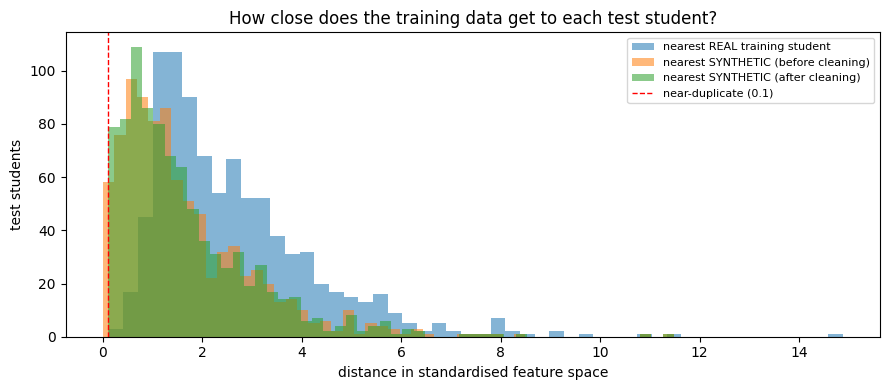

,Stage,Synthetic rows,Exact duplicates of a test student,Near-duplicates,Median dist. to nearest synthetic
0,before cleaning,76518,11,32,1.257
1,after cleaning,76480,0,0,1.269


PASS — after removing 38 rows, no test student has a copy in the training data. The comparison below is valid.


In [77]:
# ---------------------------------------------------------------------------
# 1. Locate and validate the extra training data.
# ---------------------------------------------------------------------------
PLAYGROUND_FILE = Path("data/playground_s4e6_train.csv")
playground_ready = PLAYGROUND_FILE.exists()

if not playground_ready:
    print("Kaggle Playground S4E6 training file NOT found — this section is skipped.")
    print(f"Expected at: {PLAYGROUND_FILE.resolve()}")
    print()
    print("To enable it:")
    print("  1. open https://www.kaggle.com/competitions/playground-series-s4e6/data")
    print("  2. accept the competition rules (one-off; the competition is closed)")
    print("  3. download train.csv and save it as data/playground_s4e6_train.csv")
    print("  4. re-run the notebook")
else:
    syn = pd.read_csv(PLAYGROUND_FILE)
    syn.columns = syn.columns.str.strip()
    syn = syn.rename(columns={"Nacionality": "Nationality"})
    syn = syn.drop(columns=[c for c in ["id", "Id", "ID"] if c in syn.columns])

    missing_cols = [c for c in feature_columns if c not in syn.columns]
    assert not missing_cols, f"Playground file is missing {len(missing_cols)} columns: {missing_cols}"
    assert "Target" in syn.columns, "Playground file has no Target column"

    # Same binary encoding as the real data: Dropout = 1, Enrolled and Graduate = 0
    y_syn = (syn["Target"] == "Dropout").astype(int).to_numpy()
    X_syn_raw = syn[feature_columns].astype(float).reset_index(drop=True)

    print(f"Loaded {len(X_syn_raw):,} synthetic students · {len(feature_columns)} features matched")
    print(f"  synthetic dropout rate : {y_syn.mean():.1%}")
    print(f"  real dropout rate      : {y_train.mean():.1%} (training split)")
    print(f"  ratio synthetic : real = {len(X_syn_raw) / len(y_train):.1f} : 1")
    print()
    print(syn["Target"].value_counts().to_string())

# ---------------------------------------------------------------------------
# 1b. LEAKAGE GATE — measure, clean, re-measure.
#
# The Playground data was generated by a model trained on the SAME UCI dataset
# that supplies the test set here, so the generator can reproduce a real student
# closely enough that the model would simply memorise the answer.
#
# Exact matching alone is not enough: a generated row that copies a student and
# shifts one grade by 0.1 leaves no exact match. Each SYNTHETIC row is therefore
# measured against its nearest neighbour among the real TEST students, and any
# row that lands closer than a real student ever gets is REMOVED from the
# training pool.
# ---------------------------------------------------------------------------
if playground_ready:
    from sklearn.neighbors import NearestNeighbors

    NEAR = 0.10          # distance in standardised space below which two rows are "the same student"

    X_syn_np = X_syn_raw.to_numpy()
    _sc = StandardScaler().fit(np.vstack([X_train.to_numpy(), X_syn_np]))
    Z_test  = _sc.transform(X_test.to_numpy())
    Z_train = _sc.transform(X_train.to_numpy())

    def report(Z_syn, label):
        d_syn  = NearestNeighbors(n_neighbors=1).fit(Z_syn).kneighbors(Z_test)[0].ravel()
        d_real = NearestNeighbors(n_neighbors=1).fit(Z_train).kneighbors(Z_test)[0].ravel()
        near = int((d_syn < NEAR).sum())
        print(f'  {label}')
        print(f'    near-duplicates of a test student        : {near} of {len(d_syn)} '
              f'({near / len(d_syn):.1%})')
        print(f'    median distance to nearest SYNTHETIC row : {np.median(d_syn):.3f}')
        print(f'    median distance to nearest REAL TRAIN row: {np.median(d_real):.3f}')
        return near, d_syn, d_real

    print('Leakage gate — real test students vs the synthetic training file\n')
    Z_syn_all = _sc.transform(X_syn_np)
    test_keys = {tuple(np.round(r, 3)) for r in X_test.to_numpy()}
    exact_before = len({tuple(np.round(q, 3)) for q in X_syn_np} & test_keys)
    print(f'  exact duplicates before cleaning           : {exact_before}')
    near_before, d_before, d_real = report(Z_syn_all, 'BEFORE cleaning')

    d_syn_to_test = NearestNeighbors(n_neighbors=1).fit(Z_test).kneighbors(Z_syn_all)[0].ravel()
    is_exact = np.array([tuple(np.round(q, 3)) in test_keys for q in X_syn_np])
    drop_rows = (d_syn_to_test < NEAR) | is_exact
    n_drop = int(drop_rows.sum())

    X_syn_raw = X_syn_raw.loc[~drop_rows].reset_index(drop=True)
    y_syn     = y_syn[~drop_rows]
    X_syn_np  = X_syn_raw.to_numpy()

    print(f'\n  removed {n_drop:,} synthetic rows ({n_drop / len(drop_rows):.2%}) that were '
          f'copies of a TEST student')
    print(f'  synthetic training pool: {len(drop_rows):,} -> {len(X_syn_raw):,} rows\n')

    Z_syn_clean = _sc.transform(X_syn_np)
    exact_after = len({tuple(np.round(q, 3)) for q in X_syn_np} & test_keys)
    print(f'  exact duplicates after cleaning            : {exact_after}')
    near_after, d_after, _ = report(Z_syn_clean, 'AFTER cleaning')

    leakage_ok = (exact_after == 0) and (near_after == 0)

    fig, a = plt.subplots(figsize=(9, 4))
    a.hist(d_real,   bins=50, alpha=0.55, label='nearest REAL training student')
    a.hist(d_before, bins=50, alpha=0.55, label='nearest SYNTHETIC (before cleaning)')
    a.hist(d_after,  bins=50, alpha=0.55, label='nearest SYNTHETIC (after cleaning)')
    a.axvline(NEAR, color='red', linestyle='--', linewidth=1, label=f'near-duplicate ({NEAR})')
    a.set_xlabel('distance in standardised feature space')
    a.set_ylabel('test students')
    a.set_title('How close does the training data get to each test student?')
    a.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / '25_leakage_check.png', dpi=150, bbox_inches='tight')
    plt.show()

    leakage_summary = pd.DataFrame([
        {'Stage': 'before cleaning', 'Synthetic rows': len(drop_rows),
         'Exact duplicates of a test student': exact_before,
         'Near-duplicates': near_before,
         'Median dist. to nearest synthetic': round(float(np.median(d_before)), 3)},
        {'Stage': 'after cleaning', 'Synthetic rows': len(X_syn_raw),
         'Exact duplicates of a test student': exact_after,
         'Near-duplicates': near_after,
         'Median dist. to nearest synthetic': round(float(np.median(d_after)), 3)},
    ])
    display(leakage_summary)

    if leakage_ok:
        print(f'PASS — after removing {n_drop:,} rows, no test student has a copy in the '
              f'training data. The comparison below is valid.')
    else:
        print('*** FAIL — duplicates of TEST students remain in the synthetic training file. ***')
        print('Every AUC below would be inflated by memorisation and must NOT be reported.')


### 9.1 How close is the synthetic data to the real data?

Before using it, it is worth stating *how* synthetic it is. The table below compares the marginal distribution of each variable between the 4,424 real students and the ~76,500 generated ones.

A generative model reproduces means well and tails badly, so the columns to watch are the standard deviation and the number of distinct values: a much narrower spread means the generator has smoothed away exactly the unusual students an early-warning system is supposed to find.


Marginal distribution — real (4,424) vs synthetic (76,480). Sorted by how much the generator narrowed the spread:


,real mean,syn mean,real std,syn std,real n unique,syn n unique,std ratio (syn/real)
Curricular units 2nd sem (credited),0.54,0.14,1.92,0.93,19,20,0.484
Curricular units 1st sem (credited),0.71,0.19,2.36,1.18,21,21,0.500
International,0.02,0.01,0.16,0.08,2,2,0.500
Educational special needs,0.01,0.00,0.11,0.06,2,2,0.545
Curricular units 1st sem (without evaluations),0.14,0.06,0.69,0.41,11,12,0.594
Curricular units 2nd sem (without evaluations),0.15,0.06,0.75,0.46,10,11,0.613
Mother's occupation,10.96,8.58,26.42,17.48,32,40,0.662
Father's occupation,11.03,8.88,25.26,16.81,46,56,0.665
Curricular units 1st sem (enrolled),6.27,5.89,2.48,1.67,23,24,0.673
Marital status,1.18,1.11,0.61,0.44,6,6,0.721



19 of 32 variables have a NARROWER spread in the synthetic data (ratio < 0.9) — the generator smoothed those tails away.


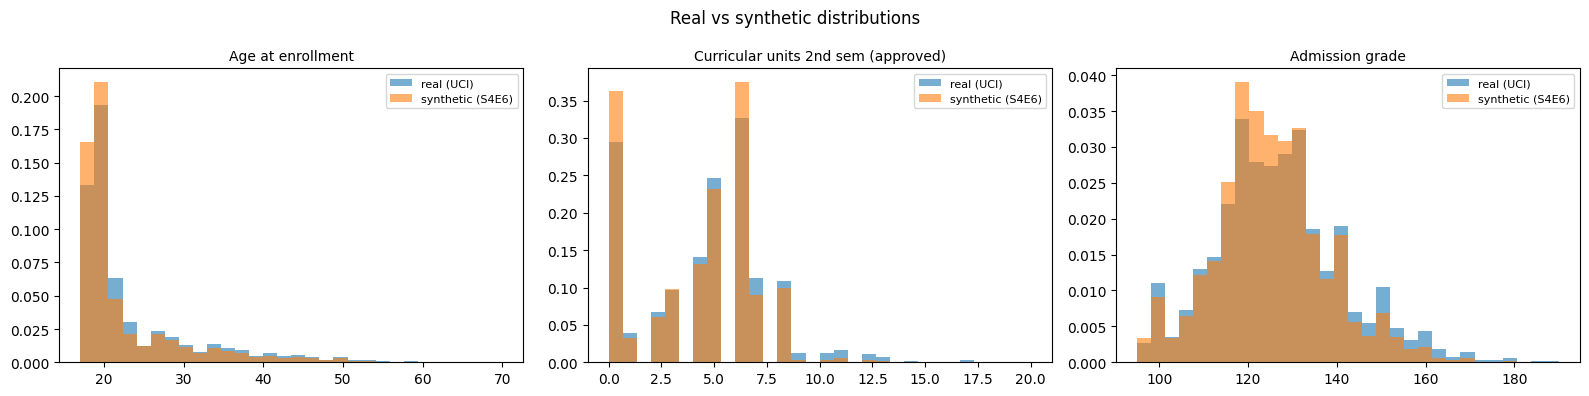

In [78]:
# ---------------------------------------------------------------------------
# 2. Real vs synthetic — marginal distributions.
# ---------------------------------------------------------------------------
if playground_ready:
    X_real_all = X.astype(float).reset_index(drop=True)

    dist_cmp = pd.DataFrame({
        "real mean":      X_real_all.mean().round(2),
        "syn mean":       X_syn_raw.mean().round(2),
        "real std":       X_real_all.std().round(2),
        "syn std":        X_syn_raw.std().round(2),
        "real n unique":  X_real_all.nunique(),
        "syn n unique":   X_syn_raw.nunique(),
    })
    dist_cmp["std ratio (syn/real)"] = (dist_cmp["syn std"] /
                                        dist_cmp["real std"].replace(0, np.nan)).round(3)
    dist_cmp = dist_cmp.sort_values("std ratio (syn/real)")

    print(f"Marginal distribution — real ({len(X_real_all):,}) vs synthetic "
          f"({len(X_syn_raw):,}). Sorted by how much the generator narrowed the spread:")
    display(dist_cmp)

    narrowed = dist_cmp[dist_cmp["std ratio (syn/real)"] < 0.9]
    print(f"\n{len(narrowed)} of {len(dist_cmp)} variables have a NARROWER spread in the "
          f"synthetic data (ratio < 0.9) — the generator smoothed those tails away.")

    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    for a, colname in zip(ax, ["Age at enrollment",
                               "Curricular units 2nd sem (approved)",
                               "Admission grade"]):
        a.hist(X_real_all[colname], bins=30, density=True, alpha=0.6, label="real (UCI)")
        a.hist(X_syn_raw[colname],  bins=30, density=True, alpha=0.6, label="synthetic (S4E6)")
        a.set_title(colname, fontsize=10)
        a.legend(fontsize=8)
    plt.suptitle("Real vs synthetic distributions")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "23_real_vs_synthetic.png", dpi=150, bbox_inches="tight")
    plt.show()


In [79]:
# ---------------------------------------------------------------------------
# 3. The experiment. Four training sets, ONE frozen real test set.
#    Hyper-parameters are the ones already selected — nothing is re-tuned, so
#    the training data is the only thing that varies.
# ---------------------------------------------------------------------------
if playground_ready:
    # Category levels must cover BOTH sources, or a code seen only in the
    # synthetic file becomes NaN and the model silently loses that row's value.
    levels_aug = {c: sorted(set(_levels[c]) | set(X_syn_raw[c].astype(int).unique()))
                  for c in CATEGORICAL_COLS}

    def enc_cat(arr):
        d = pd.DataFrame(np.asarray(arr), columns=feature_columns)
        for c in CATEGORICAL_COLS:
            d[c] = pd.Categorical(d[c].astype(int), categories=levels_aug[c])
        return d

    def enc_int(arr):
        d = pd.DataFrame(np.asarray(arr), columns=feature_columns)
        for c in CATEGORICAL_COLS:
            d[c] = d[c].astype(int)
        return d

    X_real_tr = X_train.to_numpy()
    X_syn     = X_syn_raw.to_numpy()
    X_test_np = X_test.to_numpy()

    n_real, n_syn = len(y_train), len(y_syn)
    w_real_balanced = n_syn / n_real          # so real and synthetic weigh the same in variant C

    VARIANTS = {
        "A - real only": (
            X_real_tr, y_train, np.ones(n_real)),
        "B - real + synthetic": (
            np.vstack([X_real_tr, X_syn]), np.concatenate([y_train, y_syn]),
            np.ones(n_real + n_syn)),
        "C - real + synthetic (re-weighted)": (
            np.vstack([X_real_tr, X_syn]), np.concatenate([y_train, y_syn]),
            np.concatenate([np.full(n_real, w_real_balanced), np.ones(n_syn)])),
        "D - synthetic only": (
            X_syn, y_syn, np.ones(n_syn)),
    }

    BUILDERS = {
        "LightGBM": (lambda: lgb.LGBMClassifier(objective="binary", is_unbalance=True,
                                                random_state=RANDOM_STATE, verbose=-1,
                                                **best_lgb["params"]),
                     enc_cat, {}),
        "XGBoost":  (lambda: XGBClassifier(objective="binary:logistic", eval_metric="logloss",
                                           scale_pos_weight=spw, enable_categorical=True,
                                           tree_method="hist", random_state=RANDOM_STATE,
                                           verbosity=0, **best_xgb["params"]),
                     enc_cat, {}),
        "CatBoost": (lambda: CatBoostClassifier(loss_function="Logloss",
                                                auto_class_weights="Balanced",
                                                random_seed=RANDOM_STATE, verbose=0,
                                                allow_writing_files=False, **best_cat["params"]),
                     enc_int, {"cat_features": CATEGORICAL_COLS}),
    }

    X_test_cat, X_test_int = enc_cat(X_test_np), enc_int(X_test_np)

    def _fit_augmented():
        out = {}
        for vname, (Xv, yv, wv) in VARIANTS.items():
            for mname, (build, encoder, fkw) in BUILDERS.items():
                model = build()
                model.fit(encoder(Xv), yv, sample_weight=wv, **fkw)
                out[(vname, mname)] = model
                print(f'    fitted {vname:36s} {mname:9s} on {len(yv):,} rows')
        return out

    aug_models = cached('augmentation_models', _fit_augmented,
                        extra=(len(y_syn), int(y_syn.sum()),
                               best_lgb['params'], best_xgb['params'], best_cat['params']))

    aug_rows = []
    for vname, (Xv, yv, wv) in VARIANTS.items():
        for mname in BUILDERS:
            model = aug_models[(vname, mname)]
            X_ev = X_test_int if mname == "CatBoost" else X_test_cat
            score = model.predict_proba(X_ev)[:, 1]
            pred  = np.asarray(model.predict(X_ev)).ravel()
            aug_rows.append({
                "Variant": vname, "Model": mname,
                "Train n": len(yv),
                "AUC":       round(roc_auc_score(y_test, score), 4),
                "AP":        round(average_precision_score(y_test, score), 4),
                "Recall":    round(recall_score(y_test, pred), 4),
                "Precision": round(precision_score(y_test, pred), 4),
                "F1":        round(f1_score(y_test, pred), 4),
            })
            print(f"  {vname:36s} {mname:9s} "
                  f"n={len(yv):6,d}  AUC={aug_rows[-1]['AUC']:.4f}  "
                  f"Recall={aug_rows[-1]['Recall']:.4f}")

    aug_results = pd.DataFrame(aug_rows)
    aug_results['Leakage check'] = 'PASS' if leakage_ok else 'FAIL - do not report'
    print("\nAll variants evaluated on the SAME real UCI test students:")
    display(aug_results.pivot(index="Variant", columns="Model", values="AUC"))
    display(aug_results)


  [cache] loaded  augmentation_models
  A - real only                        LightGBM  n= 3,539  AUC=0.9323  Recall=0.8310
  A - real only                        XGBoost   n= 3,539  AUC=0.9304  Recall=0.8345
  A - real only                        CatBoost  n= 3,539  AUC=0.9316  Recall=0.7993
  B - real + synthetic                 LightGBM  n=80,019  AUC=0.9364  Recall=0.8486
  B - real + synthetic                 XGBoost   n=80,019  AUC=0.9366  Recall=0.8521
  B - real + synthetic                 CatBoost  n=80,019  AUC=0.9389  Recall=0.8415
  C - real + synthetic (re-weighted)   LightGBM  n=80,019  AUC=0.9358  Recall=0.8415
  C - real + synthetic (re-weighted)   XGBoost   n=80,019  AUC=0.9352  Recall=0.8451
  C - real + synthetic (re-weighted)   CatBoost  n=80,019  AUC=0.9368  Recall=0.8310
  D - synthetic only                   LightGBM  n=76,480  AUC=0.9370  Recall=0.8415
  D - synthetic only                   XGBoost   n=76,480  AUC=0.9362  Recall=0.8451
  D - synthetic only       

Model,CatBoost,LightGBM,XGBoost
Variant,,,
A - real only,0.9316,0.9323,0.9304
B - real + synthetic,0.9389,0.9364,0.9366
C - real + synthetic (re-weighted),0.9368,0.9358,0.9352
D - synthetic only,0.9403,0.9370,0.9362


,Variant,Model,Train n,AUC,AP,Recall,Precision,F1,Leakage check
0,A - real only,LightGBM,3539,0.9323,0.9013,0.8310,0.7738,0.8014,PASS
1,A - real only,XGBoost,3539,0.9304,0.9018,0.8345,0.7822,0.8075,PASS
2,A - real only,CatBoost,3539,0.9316,0.9026,0.7993,0.7909,0.7951,PASS
3,B - real + synthetic,LightGBM,80019,0.9364,0.9105,0.8486,0.8169,0.8325,PASS
4,B - real + synthetic,XGBoost,80019,0.9366,0.9106,0.8521,0.8121,0.8316,PASS
5,B - real + synthetic,CatBoost,80019,0.9389,0.9132,0.8415,0.8270,0.8342,PASS
6,C - real + synthetic (re-weighted),LightGBM,80019,0.9358,0.9079,0.8415,0.8129,0.8270,PASS
7,C - real + synthetic (re-weighted),XGBoost,80019,0.9352,0.9101,0.8451,0.7973,0.8205,PASS
8,C - real + synthetic (re-weighted),CatBoost,80019,0.9368,0.9113,0.8310,0.8166,0.8237,PASS
9,D - synthetic only,LightGBM,76480,0.9370,0.9103,0.8415,0.8157,0.8284,PASS


Stability of the LightGBM risk factors across the four training sets:


/Users/macvn/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray

/Users/macvn/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray

/Users/macvn/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray

/Users/macvn/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray



,Variant,Top factor,Shared with main analysis (of 10)
0,A - real only,Curricular units 2nd sem (approved),10
1,B - real + synthetic,Curricular units 2nd sem (approved),8
2,C - real + synthetic (re-weighted),Curricular units 2nd sem (approved),8
3,D - synthetic only,Curricular units 2nd sem (approved),8



Top 10 risk factors per variant:


,A - real only,B - real + synthetic,C - real + synthetic (re-weighted),D - synthetic only
1,Curricular units 2nd sem (approved),Curricular units 2nd sem (approved),Curricular units 2nd sem (approved),Curricular units 2nd sem (approved)
2,Tuition fees up to date,Tuition fees up to date,Curricular units 2nd sem (grade),Tuition fees up to date
3,Curricular units 1st sem (approved),Curricular units 2nd sem (grade),Tuition fees up to date,Curricular units 2nd sem (grade)
4,Course,Curricular units 1st sem (approved),Curricular units 1st sem (approved),Curricular units 1st sem (approved)
5,Age at enrollment,Age at enrollment,Course,Age at enrollment
6,Father's occupation,Scholarship holder,Age at enrollment,Course
7,Curricular units 2nd sem (grade),Curricular units 2nd sem (enrolled),Scholarship holder,Scholarship holder
8,Mother's occupation,Course,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (enrolled)
9,Scholarship holder,Application mode,Application mode,Application mode
10,Application mode,Gender,Gender,Gender


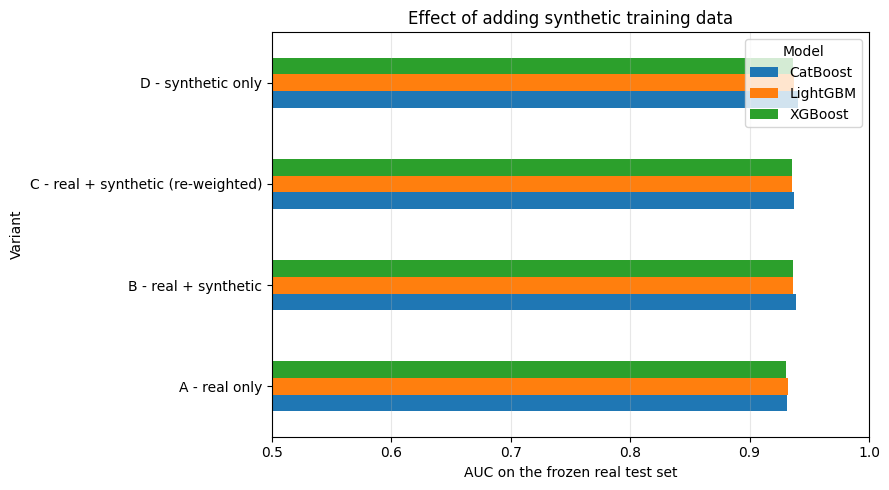

In [80]:
# ---------------------------------------------------------------------------
# 4. Effect on the risk factors — does adding synthetic data change the answer
#    to the second half of the thesis title?
# ---------------------------------------------------------------------------
if playground_ready:
    baseline_top10 = shap_tables["LightGBM"].head(10)["feature"].tolist()

    aug_shap_rows, aug_shap_tables = [], {}
    for vname in VARIANTS:
        m = aug_models[(vname, "LightGBM")]
        sv = shap.TreeExplainer(m).shap_values(enc_cat(X_test_np))
        if isinstance(sv, list):
            sv = sv[1]
        t = (pd.DataFrame({"feature": feature_columns,
                           "mean_abs_shap": np.abs(np.array(sv)).mean(axis=0)})
             .sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))
        aug_shap_tables[vname] = t
        top10 = t.head(10)["feature"].tolist()
        aug_shap_rows.append({
            "Variant": vname,
            "Top factor": top10[0],
            "Shared with main analysis (of 10)": len(set(top10) & set(baseline_top10)),
        })

    aug_shap = pd.DataFrame(aug_shap_rows)
    print("Stability of the LightGBM risk factors across the four training sets:")
    display(aug_shap)

    side_by_side = pd.DataFrame({v: t.head(10)["feature"].values
                                 for v, t in aug_shap_tables.items()},
                                index=[str(i) for i in range(1, 11)])
    print("\nTop 10 risk factors per variant:")
    display(side_by_side)

    fig, ax = plt.subplots(figsize=(9, 5))
    piv = aug_results.pivot(index="Variant", columns="Model", values="AUC")
    piv.plot(kind="barh", ax=ax)
    ax.set_xlim(0.5, 1.0)
    ax.set_xlabel("AUC on the frozen real test set")
    ax.set_title("Effect of adding synthetic training data")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "24_augmentation_experiment.png", dpi=150, bbox_inches="tight")
    plt.show()


### 9.2 Reading the augmentation experiment

Compare each variant with **A** on the same frozen test set — that is the only comparison the design supports.

**Variant D decides it.** A model trained on generated data alone, scored on real students, states exactly what the generator is worth. If D matches B, the real students added nothing once the synthetic rows were present, and any apparent gain is variance reduction on an over-flexible configuration rather than new knowledge.

**Either outcome belongs in the thesis.** If the extra data helps, the thesis reports a larger effective training set. If it does not, the finding is more interesting: *generated data drawn from the same source adds volume but no information.* Set against the previous section — where **real** data from another country did transfer — the pair makes a single point: **it is the reality of the data that matters, not its quantity.**

> **Limitation for Chương 3.** The Playground file is generated from the same UCI dataset this study trains and tests on. It is therefore not external validation and supports no claim of generalisation. The genuine external test is `Testkhoa.csv`, in the section above.


---

## 10. Saving the results

Every table and figure the thesis cites is written to disk here, so the numbers in the written chapters can always be traced back to a file produced by this notebook.

- `08_KetQua_Kaggle/` — result tables (CSV)
- `03_KetQua_Hinh/kaggle/` — figures (PNG)


In [81]:
# ---------------------------------------------------------------------------
# Write every result table to 08_KetQua_Kaggle/ so the thesis can cite a file
# rather than a number copied off the screen.
# ---------------------------------------------------------------------------
RES_DIR = Path('08_KetQua_Kaggle')
RES_DIR.mkdir(parents=True, exist_ok=True)

best_params_all = pd.DataFrame([
    {'Model': 'LightGBM', 'Validation AUC': round(best_lgb['auc'], 4),
     'Best params': str(best_lgb['params'])},
    {'Model': 'XGBoost',  'Validation AUC': round(best_xgb['auc'], 4),
     'Best params': str(best_xgb['params'])},
    {'Model': 'CatBoost', 'Validation AUC': round(best_cat['auc'], 4),
     'Best params': str(best_cat['params'])},
])

to_save = {
    'model_comparison_all.csv':  summary,
    'cv_results.csv':            cv_summary,
    'best_params_all.csv':       best_params_all,
    'threshold_sweep.csv':       threshold_table,
    'sensitivity_enrolled.csv':  sensitivity,
    'feature_importance_ranks.csv': rank_table.reset_index().rename(columns={'index': 'feature'}),
    'split_variation.csv':       split_variation,
}
for name, table in shap_tables.items():
    to_save[f'shap_importance_{name.lower()}.csv'] = table

if testkhoa_ready:
    to_save['testkhoa_summary.csv']          = testkhoa_summary
    to_save['testkhoa_transfer.csv']         = transfer_results
    to_save['testkhoa_thresholds.csv']       = transfer_thresholds
    to_save['testkhoa_shap_importance.csv']  = shap_vn
    to_save['testkhoa_vs_uci_top10.csv']     = side.reset_index()

# The augmentation experiment only exists when the Playground file is present
if playground_ready:
    to_save['augmentation_leakage_gate.csv']      = leakage_summary
    to_save['augmentation_experiment.csv']        = aug_results
    to_save['augmentation_shap_stability.csv']    = aug_shap
    to_save['distribution_real_vs_synthetic.csv'] = dist_cmp.reset_index().rename(
        columns={'index': 'feature'})

for fname, table in to_save.items():
    table.to_csv(RES_DIR / fname, index=False)
    print(f'  saved {fname:34s} ({len(table)} rows)')

figs = sorted(FIG_DIR.glob('*.png'))
print(f'\n{len(to_save)} tables in {RES_DIR}/ · {len(figs)} figures in {FIG_DIR}/')
for f in figs:
    print(f'  {f.name}')

print('\nDone.')


  saved model_comparison_all.csv           (6 rows)
  saved cv_results.csv                     (6 rows)
  saved best_params_all.csv                (3 rows)
  saved threshold_sweep.csv                (7 rows)
  saved sensitivity_enrolled.csv           (2 rows)
  saved feature_importance_ranks.csv       (32 rows)
  saved split_variation.csv                (1 rows)
  saved shap_importance_lightgbm.csv       (32 rows)
  saved shap_importance_xgboost.csv        (32 rows)
  saved shap_importance_catboost.csv       (32 rows)
  saved testkhoa_summary.csv               (4 rows)
  saved testkhoa_transfer.csv              (2 rows)
  saved testkhoa_thresholds.csv            (7 rows)
  saved testkhoa_shap_importance.csv       (19 rows)
  saved testkhoa_vs_uci_top10.csv          (10 rows)
  saved augmentation_leakage_gate.csv      (2 rows)
  saved augmentation_experiment.csv        (12 rows)
  saved augmentation_shap_stability.csv    (4 rows)
  saved distribution_real_vs_synthetic.csv (32 rows)

19 